In [1]:
# Cell 1 — Imports, paths, and configuration
# -*- coding: utf-8 -*-
"""
Final Production Notebook
CIGS Absorber Thickness Optimization
Coupled optical–electrical model with revised external validation
"""

import os
import re
import glob
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.interpolate import RegularGridInterpolator

# ============================================================
# Optional Google Drive mount
# ============================================================
USE_GOOGLE_DRIVE = True

if USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')

# ============================================================
# Paths
# ============================================================
# For Colab + Google Drive:
PROJECT_PATH = "/content/drive/MyDrive/Colab Notebooks/PV_Layer_Opt"

# Folder containing Paulson CSV files
CIGS_FOLDER = os.path.join(PROJECT_PATH, "Refracive_index", "CIGS")

# Output folders
FIG_DIR = os.path.join(PROJECT_PATH, "Figures_REVISED_VALIDATION")
RESULTS_DIR = os.path.join(PROJECT_PATH, "Results_REVISED_VALIDATION")

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("CIGS data folder:", CIGS_FOLDER)
print("Figure output folder:", FIG_DIR)
print("Results output folder:", RESULTS_DIR)


Mounted at /content/drive
CIGS data folder: /content/drive/MyDrive/Colab Notebooks/PV_Layer_Opt/Refracive_index/CIGS
Figure output folder: /content/drive/MyDrive/Colab Notebooks/PV_Layer_Opt/Figures_REVISED_VALIDATION
Results output folder: /content/drive/MyDrive/Colab Notebooks/PV_Layer_Opt/Results_REVISED_VALIDATION


In [2]:
# Cell 2 — Physical constants and fixed parameters
# ============================================================
# Physical constants
# ============================================================
q   = 1.602176634e-19      # C
h   = 6.62607015e-34       # J s
c   = 299792458.0          # m/s
kB  = 1.380649e-23         # J/K
T   = 300.0                # K
kT  = kB * T
Vth = kT / q               # thermal voltage, V

# ============================================================
# Device / model parameters
# ============================================================
# Optical stack
ALPHA_CdS_CM  = 1.0e5      # cm^-1, below CdS cutoff
CdS_CUTOFF_NM = 520.0      # nm
T_CdS_NM      = 50.0       # nm
R_BACK        = 0.75       # Mo broadband reflectance

# Transport
W_DEP       = 0.25e-6      # 250 nm depletion width
S_BACK_CM_S = 1.0e5       # cm/s
MU_N_CM2VS  = 100.0       # cm^2/V/s
D_N_M2S     = MU_N_CM2VS * Vth * 1e-4  # m^2/s

# Diode / electrical
R_S_CM2     = 0.5
R_S_SI      = R_S_CM2 * 1e-4
N_IDEALITY  = 1.5
J00_REF     = 4.0e8       # A/m^2, single calibration at x≈0.30

# Urbach correction
URBACH_EU_eV = 0.020      # 20 meV

# Final recombination model
FINAL_FORM = "quadratic"
FINAL_APEN = 1.0

# Thickness / diffusion length grids
thickness_um = np.linspace(0.05, 6.0, 500)
thickness_m  = thickness_um * 1e-6
L_um_list    = [0.3, 0.7, 1.5, 3.0]

print("Thermal voltage Vth =", Vth)
print("Electron diffusion coefficient D_n =", D_N_M2S * 1e4, "cm^2/s")


Thermal voltage Vth = 0.025851999786435535
Electron diffusion coefficient D_n = 2.5851999786435536 cm^2/s


Integrated AM1.5g power = 840.3237128274156 W/m^2


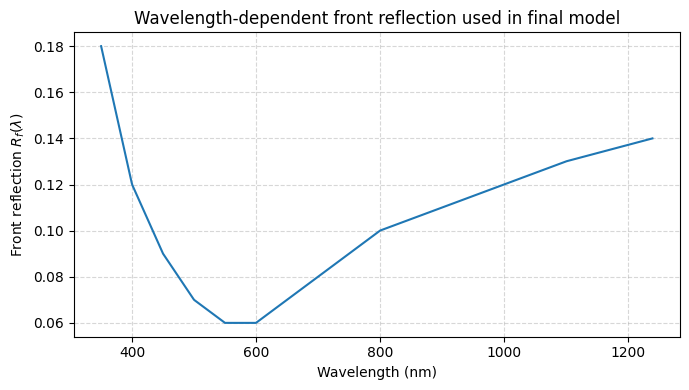

In [3]:
# Cell 3 — AM1.5g spectrum and optical-stack functions
# ============================================================
# AM1.5g spectrum through Solcore
# ============================================================
try:
    from solcore.light_source import LightSource
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "solcore", "-q"], check=False)
    from solcore.light_source import LightSource

wl_nm = np.linspace(350.0, 1240.0, 900)
wl_m  = wl_nm * 1e-9

light = LightSource(source_type="standard", version="AM1.5g", x=wl_nm)
spec = light.spectrum(wl_nm)
I_nm = np.asarray(spec[1] if isinstance(spec, tuple) else spec).ravel()  # W/m^2/nm

E_ph = h * c / wl_m
phi_per_nm = I_nm / E_ph  # photons / m^2 / s / nm
P_IN = float(np.trapezoid(I_nm, wl_nm))

print("Integrated AM1.5g power =", P_IN, "W/m^2")

# ============================================================
# CdS transmission
# ============================================================
T_CdS_lambda = np.where(
    wl_nm < CdS_CUTOFF_NM,
    np.exp(-ALPHA_CdS_CM * 100.0 * T_CdS_NM * 1e-9),
    1.0
)

# ============================================================
# Wavelength-dependent front reflection
# Digitized/simplified TMM-like front reflection for ZnO/i-ZnO/CdS
# ============================================================
_wl_ref = np.array([350, 400, 450, 500, 550, 600, 650, 700,
                    800, 900, 1000, 1100, 1240])

_R_ref = np.array([0.18, 0.12, 0.09, 0.07, 0.06, 0.06, 0.07,
                   0.08, 0.10, 0.11, 0.12, 0.13, 0.14])

R_FRONT_lambda_TMM = np.interp(wl_nm, _wl_ref, _R_ref)

plt.figure(figsize=(7, 4))
plt.plot(wl_nm, R_FRONT_lambda_TMM)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Front reflection $R_f(\\lambda)$")
plt.title("Wavelength-dependent front reflection used in final model")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [4]:
# Cell 4 — Load and interpolate Paulson optical data
# ============================================================
# Parse Paulson optical data
# ============================================================
_num_re = re.compile(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?")

def parse_paulson_csv(filepath):
    """
    Expected columns from parsed text:
    nums[0] = wavelength in nm
    nums[4] = absorption coefficient in cm^-1
    """
    wl, alpha = [], []

    with open(filepath, "r", encoding="latin1", errors="ignore") as f:
        for line in f:
            nums = _num_re.findall(line)
            if len(nums) < 5:
                continue

            try:
                wl0 = float(nums[0])
                a0  = float(nums[4])
            except ValueError:
                continue

            if wl0 <= 0 or a0 < 0:
                continue

            wl.append(wl0)
            alpha.append(a0)

    if len(wl) < 10:
        raise ValueError(f"Too few valid data points in {filepath}")

    wl = np.array(wl)
    alpha = np.array(alpha)
    order = np.argsort(wl)

    return wl[order], alpha[order]


def parse_x_from_filename(fname):
    m = re.search(r"x\s*=\s*([0-9]*\.?[0-9]+)", fname)
    if not m:
        raise ValueError(f"Cannot parse x from filename: {fname}")
    return float(m.group(1))


file_paths = sorted(glob.glob(os.path.join(CIGS_FOLDER, "*.csv")))

if not file_paths:
    raise FileNotFoundError(
        f"No CSV files found in {CIGS_FOLDER}. "
        "Place Paulson optical-constant CSV files there."
    )

files = []
for fp in file_paths:
    try:
        x = parse_x_from_filename(os.path.basename(fp))
        files.append((x, fp))
    except ValueError:
        continue

files.sort(key=lambda t: t[0])
x_vals = [t[0] for t in files]

print("Loaded compositions x =", x_vals)

# Interpolate alpha(lambda) for each measured composition
alpha_dict = {}

for x, fp in files:
    wl_data, alpha_cm = parse_paulson_csv(fp)
    alpha_dict[x] = np.interp(wl_nm, wl_data, alpha_cm) * 100.0  # cm^-1 -> m^-1

# 2D interpolation alpha(lambda, x)
x_arr = np.array(x_vals)
alpha_mat = np.stack([alpha_dict[x] for x in x_vals], axis=0)

alpha_interp = RegularGridInterpolator(
    (x_arr, wl_nm),
    alpha_mat,
    bounds_error=False,
    fill_value=None,
    method="linear"
)

print("alpha interpolation grid:", alpha_mat.shape)


Loaded compositions x = [0.0, 0.31, 0.45, 0.66, 1.0]
alpha interpolation grid: (5, 900)


In [7]:
# Cell 5 — Bandgap, Urbach correction, optics, collection, diode model
# ============================================================
#
# IMPORTANT REVISION
# ------------------
# The carrier-collection treatment is formulated so that:
#
#   A_opt(lambda) = fraction of incident photons absorbed in CIGS
#
#   IQE(lambda)   = fraction of those absorbed photons that are collected
#
#   EQE(lambda)   = A_opt(lambda) * IQE(lambda)
#
# This avoids double-counting absorption.
#
# The first and rear-reflected optical passes are treated separately
# because they have different depth-generation profiles and therefore
# experience different collection probabilities.
# ============================================================


# ============================================================
# Composition-dependent bandgap
# ============================================================
def bandgap(x):
    """
    Return the composition-dependent CIGS bandgap in eV.

    Eg(x) = 1.01 + 0.626x - 0.167x(1-x)

    Parameters
    ----------
    x : float or array-like
        Ga fraction, Ga/(Ga + In), expected in [0, 1].

    Returns
    -------
    float or ndarray
        Bandgap energy in eV.
    """
    return 1.01 + 0.626 * x - 0.167 * x * (1.0 - x)


# ============================================================
# Urbach-tail correction
# ============================================================
def apply_urbach_cutoff(alpha_m, x, Eu=URBACH_EU_eV):
    """
    Apply an exponential Urbach-tail constraint below the bandgap.

    Parameters
    ----------
    alpha_m : array-like
        Absorption coefficient in m^-1 on the global wavelength grid.
    x : float
        Ga fraction, Ga/(Ga + In).
    Eu : float
        Urbach energy in eV.

    Returns
    -------
    ndarray
        Corrected absorption coefficient in m^-1.
    """
    alpha_m = np.asarray(alpha_m, dtype=float)

    if Eu <= 0.0:
        raise ValueError("Urbach energy Eu must be positive.")

    Eg = bandgap(x)
    E_ph_eV = 1240.0 / wl_nm
    sub_bg = E_ph_eV < Eg

    if not np.any(sub_bg):
        return np.clip(alpha_m, 0.0, None)

    idx_anchor = int(np.argmin(np.abs(E_ph_eV - Eg)))
    alpha_anchor = max(float(alpha_m[idx_anchor]), 0.0)

    alpha_urbach = alpha_anchor * np.exp(
        np.clip(
            (E_ph_eV - Eg) / Eu,
            -700.0,
            700.0
        )
    )

    corrected = np.where(
        sub_bg,
        np.minimum(alpha_m, alpha_urbach),
        alpha_m
    )

    return np.clip(
        np.nan_to_num(
            corrected,
            nan=0.0,
            posinf=np.finfo(float).max,
            neginf=0.0
        ),
        0.0,
        None
    )


def alpha_for_x(x_query):
    """
    Interpolate alpha(lambda, x) for a requested Ga fraction.

    Parameters
    ----------
    x_query : float
        Ga fraction, Ga/(Ga + In).

    Returns
    -------
    ndarray
        Absorption coefficient in m^-1 on wl_nm.
    """
    x_clip = float(
        np.clip(
            x_query,
            x_arr.min(),
            x_arr.max()
        )
    )

    pts = np.column_stack([
        np.full_like(
            wl_nm,
            x_clip,
            dtype=float
        ),
        wl_nm
    ])

    alpha_m = alpha_interp(pts)
    alpha_m = apply_urbach_cutoff(
        alpha_m,
        x_clip
    )

    return np.clip(
        np.nan_to_num(
            alpha_m,
            nan=0.0,
            posinf=np.finfo(float).max,
            neginf=0.0
        ),
        0.0,
        None
    )


# ============================================================
# Two-pass optical absorptance
# ============================================================
def absorptance_two_pass(
    alpha_m,
    d,
    R_front_l=None,
    R_back=R_BACK
):
    """
    Planar incoherent two-pass CIGS absorptance.

    A_opt =
        (1 - R_front) * T_CdS *
        [
            (1 - exp(-alpha d))
            +
            R_back * exp(-alpha d)
            * (1 - exp(-alpha d))
        ]

    The first term represents absorption during the forward pass.
    The second term represents photons transmitted through the
    absorber, reflected at the rear contact, and absorbed during
    the return pass.

    Parameters
    ----------
    alpha_m : array-like
        Absorption coefficient in m^-1.
    d : float
        Absorber thickness in m.
    R_front_l : array-like or None
        Wavelength-dependent front reflectance.
    R_back : float
        Rear-contact reflectance.

    Returns
    -------
    ndarray
        Fraction of incident photons absorbed in the CIGS layer.
    """
    alpha_m = np.asarray(alpha_m, dtype=float)

    if d <= 0.0:
        return np.zeros_like(alpha_m)

    if R_front_l is None:
        R_front_l = R_FRONT_lambda_TMM

    R_front_l = np.asarray(
        R_front_l,
        dtype=float
    )

    if R_front_l.shape != alpha_m.shape:
        raise ValueError(
            "R_front_l and alpha_m must have the same shape."
        )

    R_front_eff = np.clip(
        R_front_l,
        0.0,
        1.0
    )

    R_back_eff = float(
        np.clip(
            R_back,
            0.0,
            1.0
        )
    )

    exp_ad = np.exp(
        np.clip(
            -alpha_m * d,
            -700.0,
            0.0
        )
    )

    first_abs = 1.0 - exp_ad

    second_abs = (
        R_back_eff
        * exp_ad
        * (1.0 - exp_ad)
    )

    A_opt = (
        (1.0 - R_front_eff)
        * T_CdS_lambda
        * (first_abs + second_abs)
    )

    return np.clip(
        np.nan_to_num(
            A_opt,
            nan=0.0,
            posinf=1.0,
            neginf=0.0
        ),
        0.0,
        1.0
    )


# ============================================================
# Numerical helper for stable exponential limits
# ============================================================
def _exprel(x):
    """
    Stable evaluation of

        (exp(x) - 1) / x

    with the correct limit of 1 as x -> 0.

    Works with scalars or arrays.
    """
    x = np.asarray(x, dtype=float)

    small = np.abs(x) < 1e-7

    safe_x = np.where(
        small,
        1.0,
        x
    )

    regular = np.expm1(
        np.clip(
            x,
            -700.0,
            700.0
        )
    ) / safe_x

    series = (
        1.0
        + x / 2.0
        + x**2 / 6.0
        + x**3 / 24.0
    )

    return np.where(
        small,
        series,
        regular
    )


# ============================================================
# Depth-dependent Hegedus-Shafarman / Gaertner
# collection probability
# ============================================================
def collection_probability_depth(
    z_m,
    d,
    W=W_DEP,
    L=1.0e-6,
    S_b_cm_s=S_BACK_CM_S,
    D=D_N_M2S
):
    """
    Return the carrier-collection probability P_col(z).

    Depletion region:
        P_col = 1

    Quasi-neutral region:
        P_col(z) =
            [cosh((d-z)/L) + s sinh((d-z)/L)]
            /
            [cosh(t/L) + s sinh(t/L)]

    where

        t = d - W_eff
        s = S_b L / D

    and

        W_eff = min(W, d).

    This satisfies

        P_col(W_eff) = 1

    and the finite rear-boundary condition

        D dP_col/dz = -S_b P_col

    at z = d.

    Parameters
    ----------
    z_m : float or array-like
        Depth measured from the front CIGS interface in m.
    d : float
        Absorber thickness in m.
    W : float
        Depletion width in m.
    L : float
        Minority-carrier diffusion length in m.
    S_b_cm_s : float
        Rear-surface recombination velocity in cm/s.
    D : float
        Minority-carrier diffusion coefficient in m^2/s.

    Returns
    -------
    ndarray
        Collection probability in [0, 1].
    """
    if d <= 0.0:
        return np.zeros_like(
            np.asarray(z_m, dtype=float)
        )

    if L <= 0.0:
        raise ValueError(
            "Diffusion length L must be positive."
        )

    if D <= 0.0:
        raise ValueError(
            "Diffusion coefficient D must be positive."
        )

    if S_b_cm_s < 0.0:
        raise ValueError(
            "Back-surface recombination velocity "
            "must be non-negative."
        )

    z = np.asarray(z_m, dtype=float)

    W_eff = min(
        max(float(W), 0.0),
        float(d)
    )

    t = max(
        float(d) - W_eff,
        0.0
    )

    P = np.ones_like(
        z,
        dtype=float
    )

    if t <= 0.0:
        return P

    S_b_m_s = float(S_b_cm_s) * 1e-2
    s = S_b_m_s * L / D

    mask = z > W_eff

    if np.any(mask):
        y = np.clip(
            z[mask] - W_eff,
            0.0,
            t
        )

        T = min(
            t / L,
            50.0
        )

        u = np.clip(
            (t - y) / L,
            0.0,
            50.0
        )

        denominator = (
            np.cosh(T)
            + s * np.sinh(T)
        )

        denominator = max(
            float(denominator),
            1e-30
        )

        P[mask] = (
            np.cosh(u)
            + s * np.sinh(u)
        ) / denominator

    return np.clip(
        np.nan_to_num(
            P,
            nan=0.0,
            posinf=1.0,
            neginf=0.0
        ),
        0.0,
        1.0
    )


# ============================================================
# Forward-pass absorbed-and-collected fraction
# ============================================================
def _forward_collected_fraction(
    alpha_m,
    d,
    W=W_DEP,
    L=1.0e-6,
    S_b_cm_s=S_BACK_CM_S,
    D=D_N_M2S
):
    """
    Fraction of photons entering the CIGS absorber that are
    absorbed AND collected during the first/front-to-back pass.

    This evaluates

        integral_0^d
        alpha exp(-alpha z) P_col(z) dz.

    No front-reflection or CdS transmission factor is included here.
    """
    alpha_m = np.asarray(
        alpha_m,
        dtype=float
    )

    if d <= 0.0:
        return np.zeros_like(alpha_m)

    if L <= 0.0:
        raise ValueError(
            "Diffusion length L must be positive."
        )

    if D <= 0.0:
        raise ValueError(
            "Diffusion coefficient D must be positive."
        )

    if S_b_cm_s < 0.0:
        raise ValueError(
            "Back-surface recombination velocity "
            "must be non-negative."
        )

    W_eff = min(
        max(float(W), 0.0),
        float(d)
    )

    t = max(
        float(d) - W_eff,
        0.0
    )

    # --------------------------------------------------------
    # Drift-collected depletion-region contribution
    # --------------------------------------------------------
    eta_drift = (
        1.0
        - np.exp(
            np.clip(
                -alpha_m * W_eff,
                -700.0,
                0.0
            )
        )
    )

    if t <= 0.0:
        return np.clip(
            eta_drift,
            0.0,
            1.0
        )

    # --------------------------------------------------------
    # Finite rear-boundary parameters
    # --------------------------------------------------------
    S_b_m_s = float(S_b_cm_s) * 1e-2

    s = S_b_m_s * L / D

    aL = alpha_m * L

    T = min(
        t / L,
        50.0
    )

    cosh_T = np.cosh(T)
    sinh_T = np.sinh(T)

    denominator = (
        cosh_T
        + s * sinh_T
    )

    denominator = max(
        float(denominator),
        1e-30
    )

    exp_alpha_t = np.exp(
        np.clip(
            -alpha_m * t,
            -700.0,
            0.0
        )
    )

    # --------------------------------------------------------
    # Closed-form integral in quasi-neutral region:
    #
    # integral_0^t
    # alpha exp[-alpha(W+y)] C(y) dy
    # --------------------------------------------------------
    term_plus = (
        (1.0 + s)
        * (
            np.exp(T)
            - exp_alpha_t
        )
        / (aL + 1.0)
    )

    delta = aL - 1.0

    regular_den = np.where(
        np.abs(delta) > 1e-7,
        delta,
        1.0
    )

    term_minus_regular = (
        (1.0 - s)
        * (
            np.exp(-T)
            - exp_alpha_t
        )
        / regular_den
    )

    # Correct limiting value for alpha*L -> 1.
    term_minus_limit = (
        (1.0 - s)
        * T
        * np.exp(-T)
    )

    term_minus = np.where(
        np.abs(delta) > 1e-7,
        term_minus_regular,
        term_minus_limit
    )

    eta_qnr = (
        np.exp(
            np.clip(
                -alpha_m * W_eff,
                -700.0,
                0.0
            )
        )
        * aL
        * (term_plus + term_minus)
        / (2.0 * denominator)
    )

    collected = (
        eta_drift
        + eta_qnr
    )

    return np.clip(
        np.nan_to_num(
            collected,
            nan=0.0,
            posinf=1.0,
            neginf=0.0
        ),
        0.0,
        1.0
    )


# ============================================================
# Rear-reflected-pass absorbed-and-collected fraction
# ============================================================
def _reverse_collected_fraction(
    alpha_m,
    d,
    W=W_DEP,
    L=1.0e-6,
    S_b_cm_s=S_BACK_CM_S,
    D=D_N_M2S
):
    """
    Fraction of photons entering the CIGS absorber at the FRONT
    that survive the first pass, propagate back after reflection,
    and are absorbed AND collected during the reverse pass.

    The rear-reflection coefficient R_back is NOT included here.

    This evaluates

        integral_0^d
        alpha exp[-alpha(2d-z)] P_col(z) dz.

    Therefore the final two-pass collected fraction is

        F_col =
            F_forward
            + R_back * F_reverse.

    Parameters are identical to _forward_collected_fraction().
    """
    alpha_m = np.asarray(
        alpha_m,
        dtype=float
    )

    if d <= 0.0:
        return np.zeros_like(alpha_m)

    if L <= 0.0:
        raise ValueError(
            "Diffusion length L must be positive."
        )

    if D <= 0.0:
        raise ValueError(
            "Diffusion coefficient D must be positive."
        )

    if S_b_cm_s < 0.0:
        raise ValueError(
            "Back-surface recombination velocity "
            "must be non-negative."
        )

    W_eff = min(
        max(float(W), 0.0),
        float(d)
    )

    t = max(
        float(d) - W_eff,
        0.0
    )

    # --------------------------------------------------------
    # Reverse-pass generation inside depletion region:
    #
    # integral_0^W
    # alpha exp[-alpha(2d-z)] dz
    # --------------------------------------------------------
    if W_eff > 0.0:
        reverse_drift = (
            np.exp(
                np.clip(
                    -alpha_m * (2.0 * d - W_eff),
                    -700.0,
                    0.0
                )
            )
            -
            np.exp(
                np.clip(
                    -2.0 * alpha_m * d,
                    -700.0,
                    0.0
                )
            )
        )
    else:
        reverse_drift = np.zeros_like(alpha_m)

    if t <= 0.0:
        return np.clip(
            reverse_drift,
            0.0,
            1.0
        )

    # --------------------------------------------------------
    # Finite rear-boundary parameters
    # --------------------------------------------------------
    S_b_m_s = float(S_b_cm_s) * 1e-2

    s = S_b_m_s * L / D

    aL = alpha_m * L

    T = min(
        t / L,
        50.0
    )

    cosh_T = np.cosh(T)
    sinh_T = np.sinh(T)

    denominator = (
        cosh_T
        + s * sinh_T
    )

    denominator = max(
        float(denominator),
        1e-30
    )

    # --------------------------------------------------------
    # Closed-form reverse-pass QNR integral.
    #
    # The expression is arranged to avoid the removable
    # singularity at alpha*L = 1.
    # --------------------------------------------------------

    x1 = (
        1.0 - aL
    ) * T

    term_1 = (
        (1.0 + s)
        * T
        * _exprel(x1)
    )

    x2 = (
        aL + 1.0
    ) * T

    # Stable form of
    #
    # [1 - exp(-x2)] / (aL + 1)
    #
    small_x2 = np.abs(x2) < 1e-7

    x2_safe = np.where(
        small_x2,
        1.0,
        x2
    )

    reverse_exprel = (
        -np.expm1(
            np.clip(
                -x2,
                -700.0,
                700.0
            )
        )
        / x2_safe
    )

    reverse_exprel = np.where(
        small_x2,
        1.0,
        reverse_exprel
    )

    term_2 = (
        (1.0 - s)
        * T
        * reverse_exprel
    )

    reverse_qnr = (
        aL
        * np.exp(
            np.clip(
                -alpha_m * d,
                -700.0,
                0.0
            )
        )
        * (term_1 + term_2)
        / (2.0 * denominator)
    )

    collected_reverse = (
        reverse_drift
        + reverse_qnr
    )

    return np.clip(
        np.nan_to_num(
            collected_reverse,
            nan=0.0,
            posinf=1.0,
            neginf=0.0
        ),
        0.0,
        1.0
    )


# ============================================================
# Hegedus-Shafarman / Gaertner two-pass INTERNAL
# collection efficiency
# ============================================================
def gaertner_collection(
    alpha_m,
    d,
    W=W_DEP,
    L=1.0e-6,
    S_b_cm_s=S_BACK_CM_S,
    D=D_N_M2S,
    R_back=R_BACK
):
    """
    Calculate the effective two-pass INTERNAL collection efficiency.

    IMPORTANT
    ---------
    This function now returns

        IQE =
            collected absorbed photons
            --------------------------
            total absorbed photons

    and NOT an absorption-weighted photocurrent fraction.

    Therefore it is valid to calculate

        EQE = A_opt * IQE

    without double-counting optical absorption.

    Both the first optical pass and rear-reflected pass are
    weighted by their correct depth-dependent carrier-collection
    probabilities.

    Parameters
    ----------
    alpha_m : array-like
        Absorption coefficient in m^-1.
    d : float
        Absorber thickness in m.
    W : float
        Depletion width in m.
    L : float
        Minority-carrier diffusion length in m.
    S_b_cm_s : float
        Back-surface recombination velocity in cm/s.
    D : float
        Minority-carrier diffusion coefficient in m^2/s.
    R_back : float
        Rear-contact reflectance.

    Returns
    -------
    ndarray
        Effective two-pass internal collection efficiency in [0, 1].
    """
    alpha_m = np.asarray(
        alpha_m,
        dtype=float
    )

    if d <= 0.0:
        return np.zeros_like(alpha_m)

    R_back_eff = float(
        np.clip(
            R_back,
            0.0,
            1.0
        )
    )

    # --------------------------------------------------------
    # Total INTERNAL optical absorption before front losses.
    # --------------------------------------------------------
    exp_ad = np.exp(
        np.clip(
            -alpha_m * d,
            -700.0,
            0.0
        )
    )

    first_abs = (
        1.0 - exp_ad
    )

    reverse_abs = (
        exp_ad
        * (1.0 - exp_ad)
    )

    total_abs_internal = (
        first_abs
        + R_back_eff * reverse_abs
    )

    # --------------------------------------------------------
    # Absorbed-and-collected fractions for each optical pass.
    # --------------------------------------------------------
    forward_collected = (
        _forward_collected_fraction(
            alpha_m=alpha_m,
            d=d,
            W=W,
            L=L,
            S_b_cm_s=S_b_cm_s,
            D=D
        )
    )

    reverse_collected = (
        _reverse_collected_fraction(
            alpha_m=alpha_m,
            d=d,
            W=W,
            L=L,
            S_b_cm_s=S_b_cm_s,
            D=D
        )
    )

    total_collected_internal = (
        forward_collected
        + R_back_eff * reverse_collected
    )

    # --------------------------------------------------------
    # Effective internal quantum efficiency.
    # --------------------------------------------------------
    eps = 1e-15

    IQE = np.divide(
        total_collected_internal,
        total_abs_internal,
        out=np.zeros_like(
            total_collected_internal
        ),
        where=total_abs_internal > eps
    )

    return np.clip(
        np.nan_to_num(
            IQE,
            nan=0.0,
            posinf=1.0,
            neginf=0.0
        ),
        0.0,
        1.0
    )


# ============================================================
# Direct two-pass EQE
# ============================================================
def eqe_two_pass_collection(
    alpha_m,
    d,
    R_front_l=None,
    R_back=R_BACK,
    W=W_DEP,
    L=1.0e-6,
    S_b_cm_s=S_BACK_CM_S,
    D=D_N_M2S
):
    """
    Calculate EQE directly from two-pass optical generation
    and depth-dependent carrier collection.

    Equivalent physical expression:

        EQE(lambda) =
            (1 - R_front) T_CdS
            integral_0^d
            alpha [
                exp(-alpha z)
                + R_back exp(-alpha(2d-z))
            ]
            P_col(z) dz

    This is the preferred function for the electrical model.

    Parameters
    ----------
    alpha_m : array-like
        Absorption coefficient in m^-1.
    d : float
        Absorber thickness in m.
    R_front_l : array-like or None
        Wavelength-dependent front reflectance.
    R_back : float
        Rear-contact reflectance.
    W : float
        Depletion width in m.
    L : float
        Minority-carrier diffusion length in m.
    S_b_cm_s : float
        Rear-surface recombination velocity in cm/s.
    D : float
        Minority-carrier diffusion coefficient in m^2/s.

    Returns
    -------
    ndarray
        External quantum efficiency in [0, 1].
    """
    alpha_m = np.asarray(
        alpha_m,
        dtype=float
    )

    if d <= 0.0:
        return np.zeros_like(alpha_m)

    if R_front_l is None:
        R_front_l = R_FRONT_lambda_TMM

    R_front_l = np.asarray(
        R_front_l,
        dtype=float
    )

    if R_front_l.shape != alpha_m.shape:
        raise ValueError(
            "R_front_l and alpha_m must have the same shape."
        )

    R_front_eff = np.clip(
        R_front_l,
        0.0,
        1.0
    )

    R_back_eff = float(
        np.clip(
            R_back,
            0.0,
            1.0
        )
    )

    forward_collected = (
        _forward_collected_fraction(
            alpha_m=alpha_m,
            d=d,
            W=W,
            L=L,
            S_b_cm_s=S_b_cm_s,
            D=D
        )
    )

    reverse_collected = (
        _reverse_collected_fraction(
            alpha_m=alpha_m,
            d=d,
            W=W,
            L=L,
            S_b_cm_s=S_b_cm_s,
            D=D
        )
    )

    collected_internal = (
        forward_collected
        + R_back_eff * reverse_collected
    )

    EQE = (
        (1.0 - R_front_eff)
        * T_CdS_lambda
        * collected_internal
    )

    return np.clip(
        np.nan_to_num(
            EQE,
            nan=0.0,
            posinf=1.0,
            neginf=0.0
        ),
        0.0,
        1.0
    )


# ============================================================
# Shockley-Queisser current-limit audit
# ============================================================
def SQ_Jsc_limit(Eg_eV):
    """
    Calculate the ideal above-bandgap short-circuit-current limit.

    The calculation uses the same AM1.5G wavelength grid and
    assumes unity EQE above the bandgap.

    Parameters
    ----------
    Eg_eV : float
        Bandgap energy in eV.

    Returns
    -------
    float
        Ideal current density in A/m^2.
    """
    if Eg_eV <= 0.0:
        raise ValueError(
            "Bandgap Eg_eV must be positive."
        )

    lam_g_nm = 1240.0 / Eg_eV

    mask = (
        wl_nm <= lam_g_nm
    )

    if not np.any(mask):
        return 0.0

    return q * float(
        np.trapezoid(
            phi_per_nm[mask],
            wl_nm[mask]
        )
    )


# ============================================================
# Diode saturation current
# ============================================================
def saturation_current(
    x,
    n=N_IDEALITY
):
    """
    Calculate the composition-dependent nominal saturation current.

    Parameters
    ----------
    x : float
        Ga fraction, Ga/(Ga + In).
    n : float
        Diode ideality factor.

    Returns
    -------
    float
        Saturation-current density in A/m^2.
    """
    if n <= 0.0:
        raise ValueError(
            "Ideality factor n must be positive."
        )

    exponent = (
        -bandgap(x)
        * q
        / (n * kT)
    )

    return (
        J00_REF
        * np.exp(
            np.clip(
                exponent,
                -700.0,
                700.0
            )
        )
    )


# ============================================================
# Green fill-factor approximation
# ============================================================
def fill_factor_green(
    Voc,
    Jsc,
    R_s=R_S_SI,
    n=N_IDEALITY
):
    """
    Calculate fill factor using Green's approximation with a
    first-order series-resistance correction.

    Parameters
    ----------
    Voc : float
        Open-circuit voltage in V.
    Jsc : float
        Short-circuit current density in A/m^2.
    R_s : float
        Area-normalized series resistance in ohm m^2.
    n : float
        Diode ideality factor.

    Returns
    -------
    float
        Fill factor constrained to [0, 1].
    """
    if (
        not np.isfinite(Voc)
        or not np.isfinite(Jsc)
    ):
        return np.nan

    if (
        Voc <= 0.0
        or Jsc <= 0.0
    ):
        return 0.0

    if n <= 0.0:
        raise ValueError(
            "Ideality factor n must be positive."
        )

    if R_s < 0.0:
        raise ValueError(
            "Series resistance R_s must be non-negative."
        )

    v_oc = (
        Voc
        / (n * Vth)
    )

    if v_oc <= 0.0:
        return 0.0

    log_argument = (
        v_oc
        + 0.72
    )

    if log_argument <= 0.0:
        return 0.0

    FF_ideal = (
        v_oc
        - np.log(log_argument)
    ) / (
        v_oc
        + 1.0
    )

    # Dimensionless series-resistance parameter.
    r_s = (
        R_s
        * Jsc
        / Voc
    )

    FF = (
        FF_ideal
        * (1.0 - r_s)
    )

    return float(
        np.clip(
            np.nan_to_num(
                FF,
                nan=0.0,
                posinf=1.0,
                neginf=0.0
            ),
            0.0,
            1.0
        )
    )

In [8]:
# Cell 6 — Device model and prediction helpers
# ============================================================
#
# FINAL COUPLED DEVICE MODEL
#
# IMPORTANT REVISION
# ------------------
# EQE is now calculated directly from the two-pass optical
# generation profile multiplied by the depth-dependent carrier
# collection probability:
#
#   EQE(lambda) =
#       (1 - R_front) T_CdS
#       integral_0^d alpha [
#           exp(-alpha z)
#           + R_back exp(-alpha(2d-z))
#       ] P_col(z) dz
#
# This avoids double-counting absorption.
#
# A_opt and IQE are retained as diagnostic outputs:
#
#   A_opt = two-pass CIGS absorptance
#   IQE   = collected absorbed photons / absorbed photons
#
# so that physically
#
#   EQE = A_opt * IQE
#
# up to numerical precision.
# ============================================================


def device_metrics_model(
    x,
    d,
    L_um,
    form="quadratic",
    alpha_pen=1.0,
    W=W_DEP,
    S_b=S_BACK_CM_S,
    n=N_IDEALITY,
    R_s=R_S_SI,
    R_back=R_BACK,
    R_front_l=None
):
    """
    Coupled optical-electrical CIGS device model.

    Parameters
    ----------
    x : float
        Ga fraction, Ga/(Ga + In).

    d : float
        Absorber thickness in m.

    L_um : float
        Effective minority-carrier diffusion length in micrometres.

    form : {"linear", "quadratic", "shockley"}
        Reduced-order thickness-dependent recombination scaling:

        linear:
            J0_eff = J0 * [1 + alpha_pen * (d/L)]

        quadratic:
            J0_eff = J0 * [1 + alpha_pen * (d/L)^2]

        shockley:
            J0_eff = J0 *
                     [1 + alpha_pen * (d/L)coth(d/L)]

    alpha_pen : float
        Dimensionless recombination-penalty prefactor.

    W : float
        Depletion-region width in m.

    S_b : float
        Back-surface recombination velocity in cm/s.

    n : float
        Diode ideality factor.

    R_s : float
        Area-normalized series resistance in ohm m^2.

    R_back : float
        Effective rear-contact reflectance.

    R_front_l : array-like or None
        Spectral front-stack reflectance. If None,
        R_FRONT_lambda_TMM is used.

    Returns
    -------
    dict
        Dictionary containing:

        Jsc
            Short-circuit current density in A/m^2.

        Voc
            Open-circuit voltage in V.

        FF
            Fill factor.

        eta
            Conversion efficiency in percent.

        EQE
            External quantum efficiency spectrum.

        A_opt
            Two-pass absorber absorptance.

        IQE
            Effective two-pass internal collection efficiency.

        J0
            Nominal saturation-current density.

        J0_eff
            Thickness-corrected saturation-current density.

        recombination_scaling
            Multiplicative J0 penalty.

        d_over_L
            Dimensionless thickness-to-diffusion-length ratio.
    """

    # --------------------------------------------------------
    # Basic input checks
    # --------------------------------------------------------
    if d <= 0.0:
        raise ValueError(
            "Absorber thickness d must be positive."
        )

    if L_um <= 0.0:
        raise ValueError(
            "Diffusion length L_um must be positive."
        )

    if alpha_pen < 0.0:
        raise ValueError(
            "alpha_pen must be non-negative."
        )

    if n <= 0.0:
        raise ValueError(
            "Ideality factor n must be positive."
        )

    if R_s < 0.0:
        raise ValueError(
            "Series resistance R_s must be non-negative."
        )

    if S_b < 0.0:
        raise ValueError(
            "Back-surface recombination velocity "
            "must be non-negative."
        )

    # --------------------------------------------------------
    # Composition-dependent optical constants
    # --------------------------------------------------------
    alpha_m = alpha_for_x(x)

    # Diffusion length: micrometres -> metres
    L_m = float(L_um) * 1e-6

    if R_front_l is None:
        R_front_l = R_FRONT_lambda_TMM

    R_front_l = np.asarray(
        R_front_l,
        dtype=float
    )

    if R_front_l.shape != alpha_m.shape:
        raise ValueError(
            "R_front_l and alpha(lambda) must have "
            "the same shape."
        )

    # --------------------------------------------------------
    # Optical absorptance
    # --------------------------------------------------------
    A_opt = absorptance_two_pass(
        alpha_m=alpha_m,
        d=d,
        R_front_l=R_front_l,
        R_back=R_back
    )

    # --------------------------------------------------------
    # Effective INTERNAL collection efficiency
    #
    # This is now a true IQE-like quantity:
    #
    # collected absorbed photons / absorbed photons
    # --------------------------------------------------------
    IQE = gaertner_collection(
        alpha_m=alpha_m,
        d=d,
        W=W,
        L=L_m,
        S_b_cm_s=S_b,
        D=D_N_M2S,
        R_back=R_back
    )

    # --------------------------------------------------------
    # Preferred DIRECT two-pass EQE calculation
    # --------------------------------------------------------
    EQE = eqe_two_pass_collection(
        alpha_m=alpha_m,
        d=d,
        R_front_l=R_front_l,
        R_back=R_back,
        W=W,
        L=L_m,
        S_b_cm_s=S_b,
        D=D_N_M2S
    )

    # --------------------------------------------------------
    # Physical/numerical guard
    # --------------------------------------------------------
    EQE = np.clip(
        np.nan_to_num(
            EQE,
            nan=0.0,
            posinf=1.0,
            neginf=0.0
        ),
        0.0,
        1.0
    )

    A_opt = np.clip(
        np.nan_to_num(
            A_opt,
            nan=0.0,
            posinf=1.0,
            neginf=0.0
        ),
        0.0,
        1.0
    )

    IQE = np.clip(
        np.nan_to_num(
            IQE,
            nan=0.0,
            posinf=1.0,
            neginf=0.0
        ),
        0.0,
        1.0
    )

    # --------------------------------------------------------
    # Optional internal consistency check
    #
    # Direct EQE and A_opt * IQE should agree because IQE was
    # defined from the same two-pass generation model.
    # --------------------------------------------------------
    EQE_from_factorization = A_opt * IQE

    eqe_consistency_error = float(
        np.nanmax(
            np.abs(
                EQE
                - EQE_from_factorization
            )
        )
    )

    # --------------------------------------------------------
    # Short-circuit current
    # --------------------------------------------------------
    Jsc = (
        q
        * float(
            np.trapezoid(
                EQE * phi_per_nm,
                wl_nm
            )
        )
    )

    if not np.isfinite(Jsc):
        Jsc = 0.0

    Jsc = max(
        float(Jsc),
        0.0
    )

    # --------------------------------------------------------
    # Thickness-dependent recombination penalty
    # --------------------------------------------------------
    ratio = (
        float(d)
        / L_m
    )

    if form == "linear":

        scaling = (
            1.0
            + alpha_pen * ratio
        )

    elif form == "quadratic":

        scaling = (
            1.0
            + alpha_pen * ratio**2
        )

    elif form == "shockley":

        ratio_safe = np.clip(
            ratio,
            1e-8,
            50.0
        )

        coth_ratio = (
            1.0
            / np.tanh(ratio_safe)
        )

        scaling = (
            1.0
            + alpha_pen
            * ratio
            * coth_ratio
        )

    else:
        raise ValueError(
            f"Unknown recombination form: {form}"
        )

    scaling = max(
        float(scaling),
        1.0
    )

    # --------------------------------------------------------
    # Nominal and effective saturation currents
    # --------------------------------------------------------
    J0 = saturation_current(
        x=x,
        n=n
    )

    J0_eff = (
        J0
        * scaling
    )

    # --------------------------------------------------------
    # Open-circuit voltage
    # --------------------------------------------------------
    if (
        Jsc > 0.0
        and J0_eff > 0.0
        and np.isfinite(J0_eff)
    ):
        Voc = (
            n
            * Vth
            * np.log1p(
                Jsc / J0_eff
            )
        )
    else:
        Voc = 0.0

    Voc = max(
        float(
            np.nan_to_num(
                Voc,
                nan=0.0,
                posinf=0.0,
                neginf=0.0
            )
        ),
        0.0
    )

    # --------------------------------------------------------
    # Fill factor
    # --------------------------------------------------------
    FF = fill_factor_green(
        Voc=Voc,
        Jsc=Jsc,
        R_s=R_s,
        n=n
    )

    FF = float(
        np.clip(
            np.nan_to_num(
                FF,
                nan=0.0,
                posinf=1.0,
                neginf=0.0
            ),
            0.0,
            1.0
        )
    )

    # --------------------------------------------------------
    # Efficiency
    #
    # Jsc [A/m^2] * Voc [V] = W/m^2
    # --------------------------------------------------------
    eta = (
        100.0
        * Jsc
        * Voc
        * FF
        / P_IN
    )

    eta = max(
        float(
            np.nan_to_num(
                eta,
                nan=0.0,
                posinf=0.0,
                neginf=0.0
            )
        ),
        0.0
    )

    # --------------------------------------------------------
    # Return all useful quantities
    # --------------------------------------------------------
    return {
        "Jsc": Jsc,
        "Voc": Voc,
        "FF": FF,
        "eta": eta,

        "EQE": EQE,
        "A_opt": A_opt,
        "IQE": IQE,

        "J0": J0,
        "J0_eff": J0_eff,

        "recombination_scaling": scaling,
        "d_over_L": ratio,

        "eqe_consistency_error": eqe_consistency_error
    }


# ============================================================
# Optimum-thickness prediction helper
# ============================================================
def predict_optimum(
    x,
    L_um,
    form="quadratic",
    alpha_pen=1.0
):
    """
    Find the absorber thickness that maximizes efficiency for a
    specified composition and diffusion length.

    Parameters
    ----------
    x : float
        Ga fraction.

    L_um : float
        Diffusion length in micrometres.

    form : str
        Recombination-scaling form.

    alpha_pen : float
        Recombination-penalty prefactor.

    Returns
    -------
    d_opt_um : float
        Model-derived optimum absorber thickness in micrometres.

    eta_max : float
        Maximum conversion efficiency in percent.
    """

    arr_eta = np.zeros_like(
        thickness_m,
        dtype=float
    )

    for i, d in enumerate(
        thickness_m
    ):
        result = device_metrics_model(
            x=x,
            d=d,
            L_um=L_um,
            form=form,
            alpha_pen=alpha_pen
        )

        arr_eta[i] = result["eta"]

    idx = int(
        np.nanargmax(
            arr_eta
        )
    )

    d_opt_um = float(
        thickness_um[idx]
    )

    eta_max = float(
        arr_eta[idx]
    )

    return (
        d_opt_um,
        eta_max
    )


# ============================================================
# Internal EQE-factorization sanity check
# ============================================================
print("=" * 90)
print("CELL 6 — TWO-PASS EQE CONSISTENCY CHECK")
print("=" * 90)

_test = device_metrics_model(
    x=0.30,
    d=1.5e-6,
    L_um=1.5,
    form="quadratic",
    alpha_pen=1.0
)

print(
    "max |EQE_direct - A_opt*IQE| = "
    f"{_test['eqe_consistency_error']:.3e}"
)

print(
    "Nominal test point:"
)

print(
    f"Jsc = {_test['Jsc'] * 0.1:.3f} mA/cm^2"
)

print(
    f"Voc = {_test['Voc']:.4f} V"
)

print(
    f"FF  = {_test['FF']:.4f}"
)

print(
    f"eta = {_test['eta']:.3f} %"
)

if _test["eqe_consistency_error"] < 1e-8:
    print(
        "PASS: direct EQE and A_opt*IQE are numerically consistent."
    )
else:
    print(
        "WARNING: inspect the two-pass EQE / IQE implementation."
    )

CELL 6 — TWO-PASS EQE CONSISTENCY CHECK
max |EQE_direct - A_opt*IQE| = 1.110e-16
Nominal test point:
Jsc = 34.185 mA/cm^2
Voc = 0.5940 V
FF  = 0.7466
eta = 18.040 %
PASS: direct EQE and A_opt*IQE are numerically consistent.


BACK-SURFACE RECOMBINATION MONOTONICITY AUDIT


,S_back_cm_s,Jsc_mAcm2,Voc_V,FF,eta_percent
0,100.00,35.343,0.5953,0.7462,18.683
1,316.23,35.330,0.5953,0.7462,18.676
2,1000.00,35.293,0.5953,0.7462,18.655
3,3162.28,35.186,0.5951,0.7462,18.596
4,10000.00,34.935,0.5949,0.7463,18.457
5,31622.78,34.538,0.5944,0.7464,18.236
6,100000.00,34.185,0.5940,0.7466,18.040
7,316227.77,33.999,0.5938,0.7466,17.937
8,1000000.00,33.927,0.5937,0.7466,17.897
9,3162277.66,33.902,0.5937,0.7466,17.884


Jsc decreases monotonically with S_back: True
Efficiency decreases monotonically with S_back: True


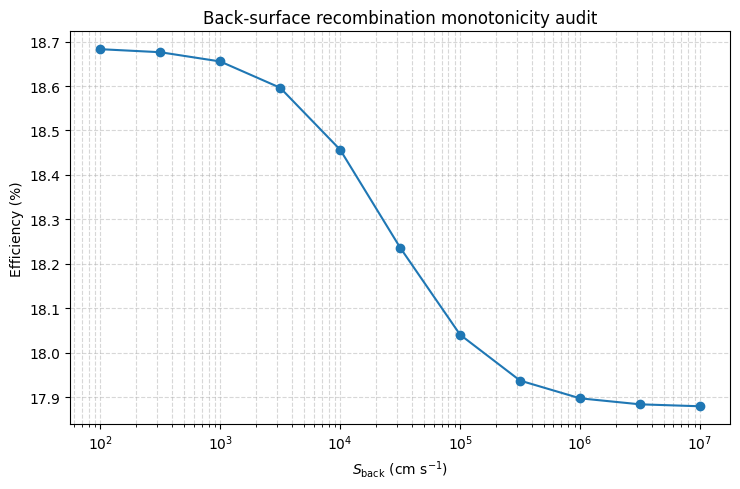

Saved: /content/drive/MyDrive/Colab Notebooks/PV_Layer_Opt/Results_REVISED_VALIDATION/Sback_Monotonicity_Audit.csv
Saved: /content/drive/MyDrive/Colab Notebooks/PV_Layer_Opt/Figures_REVISED_VALIDATION/Sback_Monotonicity_Audit.png


In [9]:
# Cell 6A — Back-surface recombination monotonicity audit
# ============================================================
# A physically consistent collection model should not predict
# improved collection when S_back is increased.
# ============================================================

x_test = 0.30
d_test_um = 1.50
L_test_um = 1.50

S_back_test_values = np.logspace(2, 7, 11)

sback_audit_rows = []

for S_value in S_back_test_values:
    result = device_metrics_model(
        x=x_test,
        d=d_test_um * 1e-6,
        L_um=L_test_um,
        form=FINAL_FORM,
        alpha_pen=FINAL_APEN,
        S_b=S_value
    )

    sback_audit_rows.append({
        "S_back_cm_s": S_value,
        "Jsc_mAcm2": 0.1 * result["Jsc"],
        "Voc_V": result["Voc"],
        "FF": result["FF"],
        "eta_percent": result["eta"]
    })

sback_audit = pd.DataFrame(sback_audit_rows)

print("=" * 90)
print("BACK-SURFACE RECOMBINATION MONOTONICITY AUDIT")
print("=" * 90)
display(sback_audit.round({
    "S_back_cm_s": 2,
    "Jsc_mAcm2": 3,
    "Voc_V": 4,
    "FF": 4,
    "eta_percent": 3
}))

jsc_monotonic = np.all(
    np.diff(sback_audit["Jsc_mAcm2"].to_numpy()) <= 1e-10
)

eta_monotonic = np.all(
    np.diff(sback_audit["eta_percent"].to_numpy()) <= 1e-10
)

print("Jsc decreases monotonically with S_back:", jsc_monotonic)
print("Efficiency decreases monotonically with S_back:", eta_monotonic)

if not jsc_monotonic or not eta_monotonic:
    raise RuntimeError(
        "Back-surface recombination audit failed: increasing S_back "
        "does not monotonically reduce collection/performance."
    )

audit_csv = os.path.join(
    RESULTS_DIR,
    "Sback_Monotonicity_Audit.csv"
)
sback_audit.to_csv(audit_csv, index=False)

plt.figure(figsize=(7.5, 5.0))
plt.semilogx(
    sback_audit["S_back_cm_s"],
    sback_audit["eta_percent"],
    "o-"
)
plt.xlabel(r"$S_{\mathrm{back}}$ (cm s$^{-1}$)")
plt.ylabel("Efficiency (%)")
plt.title("Back-surface recombination monotonicity audit")
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.tight_layout()

audit_fig = os.path.join(
    FIG_DIR,
    "Sback_Monotonicity_Audit.png"
)
plt.savefig(audit_fig, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", audit_csv)
print("Saved:", audit_fig)

In [10]:

# Cell 7 — Audited external-validation datasets and helper functions
# ============================================================
# IMPORTANT VALIDATION PRINCIPLE
# ============================================================
# A reported fabricated absorber thickness is not automatically
# an experimentally established optimum thickness.
#
# The revised validation therefore uses:
#   A) performance prediction at the measured thickness;
#   B) thickness-trend comparison against controlled thickness series;
#   C) separate treatment of lifetime and EBIC collection-profile data.
#
# The quadratic recombination form and alpha_pen = 1.0 are retained
# here as nominal model assumptions, not as values re-fitted to the
# revised validation datasets.

# ============================================================
# A) Direct scalar-transport case: Nichterwitz et al. (2013)
# ============================================================
performance_devices = [
    {
        "source": "Nichterwitz et al. (2013)",
        "x": 0.00,
        "d_exp_um": 2.00,
        "L_um": 0.420,
        "Jsc_exp_mAcm2": 40.5,
        "Voc_exp_V": 0.460,
        "FF_exp": 0.717,
        "eta_exp_percent": 13.4,
        "transport_method": "cross-sectional EBIC",
        "classification": "Primary scalar-L case",
    }
]

# ============================================================
# B) Lundberg et al. (2003) thickness-series data
# ============================================================
# These four rows are the explicitly tabulated best devices at each
# thickness and contain a Ga-rich bottom layer. They are therefore
# treated as a GRADED thickness benchmark, not as a homogeneous series.
#
# Replace or supplement these rows when digitized homogeneous-series
# values from the relevant Lundberg figure are available.
lundberg_graded = pd.DataFrame([
    {"d_um": 1.80, "cgs_bottom_nm": 100, "Jsc_exp_mAcm2": 31.9,
     "Voc_exp_V": 0.660, "FF_exp": 0.760, "eta_exp_percent": 16.1},
    {"d_um": 1.00, "cgs_bottom_nm": 50, "Jsc_exp_mAcm2": 28.8,
     "Voc_exp_V": 0.690, "FF_exp": 0.755, "eta_exp_percent": 15.0},
    {"d_um": 0.60, "cgs_bottom_nm": 100, "Jsc_exp_mAcm2": 22.7,
     "Voc_exp_V": 0.690, "FF_exp": 0.778, "eta_exp_percent": 12.1},
    {"d_um": 0.15, "cgs_bottom_nm": 10, "Jsc_exp_mAcm2": 13.6,
     "Voc_exp_V": 0.600, "FF_exp": 0.590, "eta_exp_percent": 4.8},
]).sort_values("d_um").reset_index(drop=True)

# Optional digitized homogeneous series.
# Expected columns:
# d_um, Jsc_exp_mAcm2, Voc_exp_V, FF_exp, eta_exp_percent
LUNDBERG_HOMOGENEOUS_CSV = os.path.join(
    PROJECT_PATH, "Validation_Data", "Lundberg_2003_homogeneous_digitized.csv"
)

# ============================================================
# C) Thomas et al. high-Ga lifetime/performance series
# ============================================================
thomas_devices = pd.DataFrame([
    {"x": 0.13, "tau_ns": 160, "Jsc_exp_mAcm2": 34.7,
     "Voc_exp_V": 0.560, "FF_exp": 0.75, "eta_exp_percent": 14.9},
    {"x": 0.34, "tau_ns": 760, "Jsc_exp_mAcm2": 29.8,
     "Voc_exp_V": 0.730, "FF_exp": 0.76, "eta_exp_percent": 16.7},
    {"x": 0.51, "tau_ns": 320, "Jsc_exp_mAcm2": 25.5,
     "Voc_exp_V": 0.780, "FF_exp": 0.77, "eta_exp_percent": 15.2},
    {"x": 0.67, "tau_ns": 140, "Jsc_exp_mAcm2": 21.1,
     "Voc_exp_V": 0.830, "FF_exp": 0.71, "eta_exp_percent": 12.8},
    {"x": 0.83, "tau_ns": 80, "Jsc_exp_mAcm2": 14.8,
     "Voc_exp_V": 0.860, "FF_exp": 0.65, "eta_exp_percent": 8.3},
])

# Diffusion-coefficient range used only to translate measured lifetime
# into an L interval. Edit if a better literature-supported range is adopted.
D_RANGE_CM2_S = (1.0, 3.0)

# ============================================================
# D) Optional Bissig digitized collection-profile input
# ============================================================
# Expected columns:
# depth_um, collection_probability
BISSIG_EBIC_CSV = os.path.join(
    PROJECT_PATH, "Validation_Data", "Bissig_2016_passivated_EBIC_digitized.csv"
)

# ============================================================
# Unit conversion and evaluation helpers
# ============================================================
def A_m2_to_mA_cm2(value):
    return 0.1 * float(value)


def evaluate_at_measured_thickness(device):
    """Evaluate the model at the reported absorber thickness."""
    result = device_metrics_model(
        x=device["x"],
        d=device["d_exp_um"] * 1e-6,
        L_um=device["L_um"],
        form=FINAL_FORM,
        alpha_pen=FINAL_APEN
    )

    row = dict(device)
    row.update({
        "Jsc_pred_mAcm2": A_m2_to_mA_cm2(result["Jsc"]),
        "Voc_pred_V": result["Voc"],
        "FF_pred": result["FF"],
        "eta_pred_percent": result["eta"],
    })

    row["Delta_Jsc_mAcm2"] = row["Jsc_pred_mAcm2"] - row["Jsc_exp_mAcm2"]
    row["Delta_Voc_V"] = row["Voc_pred_V"] - row["Voc_exp_V"]
    row["Delta_FF"] = row["FF_pred"] - row["FF_exp"]
    row["Delta_eta_pp"] = row["eta_pred_percent"] - row["eta_exp_percent"]

    row["AbsErr_Jsc_mAcm2"] = abs(row["Delta_Jsc_mAcm2"])
    row["AbsErr_Voc_V"] = abs(row["Delta_Voc_V"])
    row["AbsErr_FF"] = abs(row["Delta_FF"])
    row["AbsErr_eta_pp"] = abs(row["Delta_eta_pp"])

    return row


def lifetime_to_L_um(tau_ns, D_cm2_s):
    """Convert lifetime and diffusion coefficient to diffusion length in micrometres."""
    tau_s = float(tau_ns) * 1e-9
    L_cm = np.sqrt(float(D_cm2_s) * tau_s)
    return 1e4 * L_cm


def evaluate_thickness_points(x, d_values_um, L_um):
    """Evaluate Jsc, Voc, FF, and eta at a sequence of thicknesses."""
    rows = []
    for d_um in np.asarray(d_values_um, dtype=float):
        r = device_metrics_model(
            x=x,
            d=d_um * 1e-6,
            L_um=L_um,
            form=FINAL_FORM,
            alpha_pen=FINAL_APEN
        )
        rows.append({
            "d_um": d_um,
            "L_um": L_um,
            "Jsc_pred_mAcm2": A_m2_to_mA_cm2(r["Jsc"]),
            "Voc_pred_V": r["Voc"],
            "FF_pred": r["FF"],
            "eta_pred_percent": r["eta"],
        })
    return pd.DataFrame(rows)


print("Audited validation datasets loaded.")
print("Direct scalar-L cases:", len(performance_devices))
print("Lundberg graded thickness points:", len(lundberg_graded))
print("Thomas high-Ga cases:", len(thomas_devices))


Audited validation datasets loaded.
Direct scalar-L cases: 1
Lundberg graded thickness points: 4
Thomas high-Ga cases: 5


In [11]:

# Cell 8 — Revised Table 5: performance at measured thickness
# ============================================================
# Evaluate direct scalar-L cases without optimizing thickness
# ============================================================
table5_rows = [evaluate_at_measured_thickness(d) for d in performance_devices]
table5 = pd.DataFrame(table5_rows)

table5_columns = [
    "source", "classification", "transport_method",
    "x", "d_exp_um", "L_um",
    "Jsc_exp_mAcm2", "Jsc_pred_mAcm2", "Delta_Jsc_mAcm2",
    "Voc_exp_V", "Voc_pred_V", "Delta_Voc_V",
    "FF_exp", "FF_pred", "Delta_FF",
    "eta_exp_percent", "eta_pred_percent", "Delta_eta_pp"
]
table5 = table5[table5_columns]

print("=" * 120)
print("REVISED TABLE 5 — PERFORMANCE PREDICTION AT REPORTED THICKNESS")
print("=" * 120)
display(table5.round({
    "x": 2,
    "d_exp_um": 3,
    "L_um": 3,
    "Jsc_exp_mAcm2": 2,
    "Jsc_pred_mAcm2": 2,
    "Delta_Jsc_mAcm2": 2,
    "Voc_exp_V": 3,
    "Voc_pred_V": 3,
    "Delta_Voc_V": 3,
    "FF_exp": 3,
    "FF_pred": 3,
    "Delta_FF": 3,
    "eta_exp_percent": 2,
    "eta_pred_percent": 2,
    "Delta_eta_pp": 2,
}))

table5_csv = os.path.join(RESULTS_DIR, "Table5_Performance_at_Measured_Thickness.csv")
table5.to_csv(table5_csv, index=False)
print("Saved:", table5_csv)

# Do not report dataset-level MAE from a single case as broad validation.
if len(table5) > 1:
    print("\nAggregate absolute errors:")
    print("MAE Jsc =", table5["Delta_Jsc_mAcm2"].abs().mean(), "mA/cm^2")
    print("MAE Voc =", table5["Delta_Voc_V"].abs().mean(), "V")
    print("MAE FF  =", table5["Delta_FF"].abs().mean())
    print("MAE eta =", table5["Delta_eta_pp"].abs().mean(), "percentage points")
else:
    print("\nOnly one strict scalar-L case is currently included.")
    print("Report device-level errors, not a broad dataset-level MAE.")


REVISED TABLE 5 — PERFORMANCE PREDICTION AT REPORTED THICKNESS


,source,classification,transport_method,x,d_exp_um,L_um,Jsc_exp_mAcm2,Jsc_pred_mAcm2,Delta_Jsc_mAcm2,Voc_exp_V,Voc_pred_V,Delta_Voc_V,FF_exp,FF_pred,Delta_FF,eta_exp_percent,eta_pred_percent,Delta_eta_pp
0,Nichterwitz et al. (2013),Primary scalar-L case,cross-sectional EBIC,0.0,2.0,0.42,40.5,36.21,-4.29,0.46,0.348,-0.112,0.717,0.637,-0.08,13.4,9.54,-3.86


Saved: /content/drive/MyDrive/Colab Notebooks/PV_Layer_Opt/Results_REVISED_VALIDATION/Table5_Performance_at_Measured_Thickness.csv

Only one strict scalar-L case is currently included.
Report device-level errors, not a broad dataset-level MAE.


In [12]:

# Cell 9 — Lundberg thickness-series model envelopes
# ============================================================
# Direct comparison uses x ≈ 0.30.
# L is not independently reported by Lundberg et al.; therefore
# it is varied as an uncertainty parameter rather than claimed
# as an independently known validation input.
# ============================================================
X_LUNDBERG = 0.30
L_LUNDBERG_GRID_UM = np.linspace(0.30, 3.00, 80)

# Use digitized homogeneous data when available; otherwise use
# the explicitly tabulated graded benchmark and label it accordingly.
if os.path.exists(LUNDBERG_HOMOGENEOUS_CSV):
    lundberg_data = pd.read_csv(LUNDBERG_HOMOGENEOUS_CSV)
    required = {
        "d_um", "Jsc_exp_mAcm2", "Voc_exp_V",
        "FF_exp", "eta_exp_percent"
    }
    missing = required.difference(lundberg_data.columns)
    if missing:
        raise ValueError(
            f"Lundberg homogeneous CSV is missing columns: {sorted(missing)}"
        )
    lundberg_series_label = "Homogeneous x≈0.30 series (digitized)"
    lundberg_is_direct_uniform_comparison = True
else:
    lundberg_data = lundberg_graded.copy()
    lundberg_series_label = "Ga-back-graded tabulated benchmark"
    lundberg_is_direct_uniform_comparison = False

d_eval_um = np.sort(lundberg_data["d_um"].to_numpy(dtype=float))

# Evaluate each L value at the experimental thicknesses.
lundberg_model_rows = []
for L_um in L_LUNDBERG_GRID_UM:
    pred = evaluate_thickness_points(X_LUNDBERG, d_eval_um, L_um)
    lundberg_model_rows.append(pred)

lundberg_model_all = pd.concat(lundberg_model_rows, ignore_index=True)

# Pointwise uncertainty envelopes over L.
envelope_rows = []
for d_um in d_eval_um:
    group = lundberg_model_all[np.isclose(lundberg_model_all["d_um"], d_um)]
    envelope_rows.append({
        "d_um": d_um,
        "Jsc_lo": group["Jsc_pred_mAcm2"].min(),
        "Jsc_hi": group["Jsc_pred_mAcm2"].max(),
        "Voc_lo": group["Voc_pred_V"].min(),
        "Voc_hi": group["Voc_pred_V"].max(),
        "FF_lo": group["FF_pred"].min(),
        "FF_hi": group["FF_pred"].max(),
        "eta_lo": group["eta_pred_percent"].min(),
        "eta_hi": group["eta_pred_percent"].max(),
    })

lundberg_envelope = pd.DataFrame(envelope_rows)

print("=" * 100)
print("LUNDBERG THICKNESS-SERIES INPUT")
print("=" * 100)
print("Series used:", lundberg_series_label)
print("Uniform-composition direct comparison:", lundberg_is_direct_uniform_comparison)
display(lundberg_data)

lundberg_input_csv = os.path.join(RESULTS_DIR, "Lundberg_Thickness_Series_Input.csv")
lundberg_envelope_csv = os.path.join(RESULTS_DIR, "Lundberg_Model_L_Envelope.csv")
lundberg_data.to_csv(lundberg_input_csv, index=False)
lundberg_envelope.to_csv(lundberg_envelope_csv, index=False)

print("Saved:", lundberg_input_csv)
print("Saved:", lundberg_envelope_csv)


LUNDBERG THICKNESS-SERIES INPUT
Series used: Ga-back-graded tabulated benchmark
Uniform-composition direct comparison: False


,d_um,cgs_bottom_nm,Jsc_exp_mAcm2,Voc_exp_V,FF_exp,eta_exp_percent
0,0.15,10,13.6,0.60,0.590,4.8
1,0.60,100,22.7,0.69,0.778,12.1
2,1.00,50,28.8,0.69,0.755,15.0
3,1.80,100,31.9,0.66,0.760,16.1


Saved: /content/drive/MyDrive/Colab Notebooks/PV_Layer_Opt/Results_REVISED_VALIDATION/Lundberg_Thickness_Series_Input.csv
Saved: /content/drive/MyDrive/Colab Notebooks/PV_Layer_Opt/Results_REVISED_VALIDATION/Lundberg_Model_L_Envelope.csv


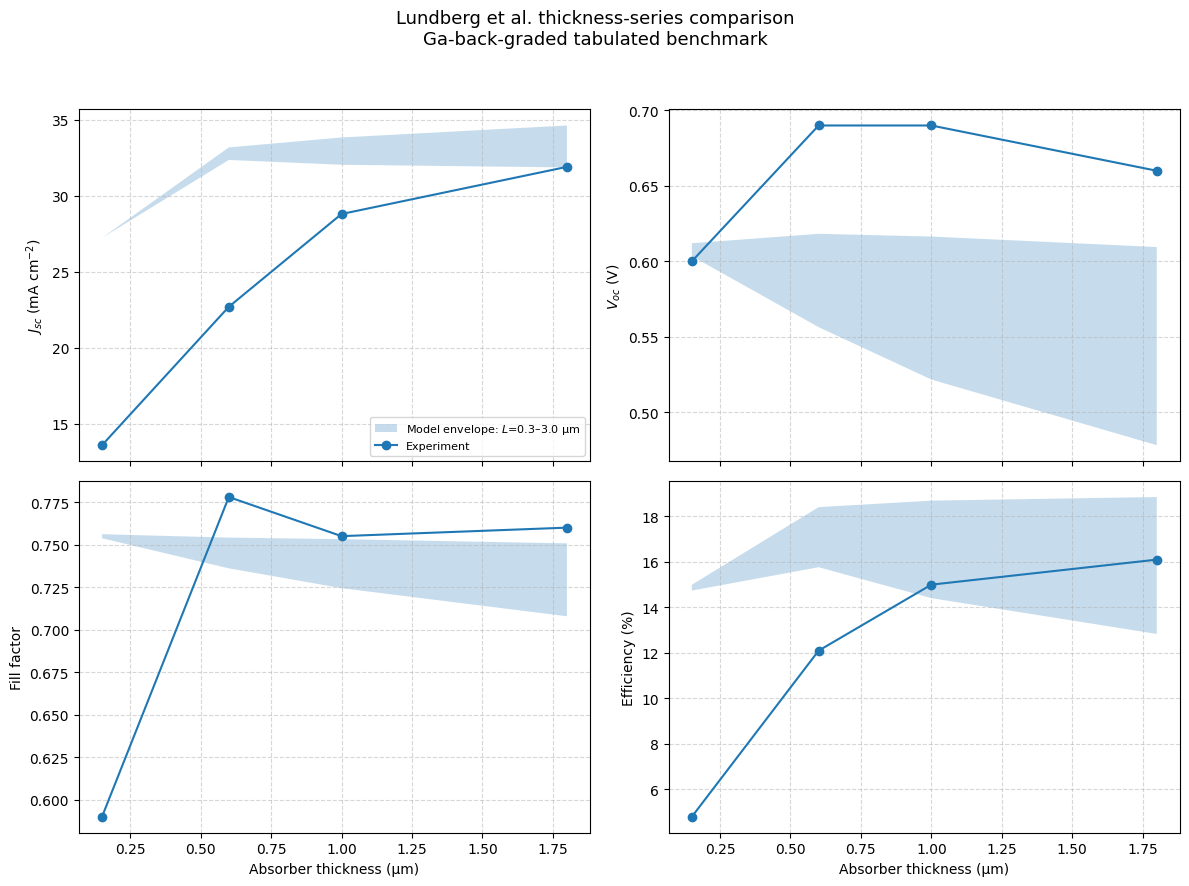

Saved: /content/drive/MyDrive/Colab Notebooks/PV_Layer_Opt/Figures_REVISED_VALIDATION/Fig3_Lundberg_Thickness_Trends.pdf
Saved: /content/drive/MyDrive/Colab Notebooks/PV_Layer_Opt/Figures_REVISED_VALIDATION/Fig3_Lundberg_Thickness_Trends.png

CAUTION:
The plotted experimental points are Ga-back-graded devices.
Use them as a qualitative thickness benchmark until the
homogeneous-series points are digitized and supplied.


In [13]:

# Cell 10 — Revised Figure 3: Lundberg thickness trends
# ============================================================
# Four panels are used because the manuscript comparison involves
# Jsc, Voc, FF, and efficiency. The shaded region is the model
# envelope over the prescribed L range, not a statistical confidence band.
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True)

plot_specs = [
    ("Jsc_exp_mAcm2", "Jsc_lo", "Jsc_hi",
     r"$J_{sc}$ (mA cm$^{-2}$)", axes[0, 0]),
    ("Voc_exp_V", "Voc_lo", "Voc_hi",
     r"$V_{oc}$ (V)", axes[0, 1]),
    ("FF_exp", "FF_lo", "FF_hi",
     "Fill factor", axes[1, 0]),
    ("eta_exp_percent", "eta_lo", "eta_hi",
     "Efficiency (%)", axes[1, 1]),
]

for exp_col, lo_col, hi_col, ylabel, ax in plot_specs:
    ax.fill_between(
        lundberg_envelope["d_um"],
        lundberg_envelope[lo_col],
        lundberg_envelope[hi_col],
        alpha=0.25,
        label=rf"Model envelope: $L$={L_LUNDBERG_GRID_UM.min():.1f}–{L_LUNDBERG_GRID_UM.max():.1f} µm"
    )
    ax.plot(
        lundberg_data["d_um"],
        lundberg_data[exp_col],
        "o-",
        linewidth=1.5,
        markersize=6,
        label="Experiment"
    )
    ax.set_ylabel(ylabel)
    ax.grid(True, linestyle="--", alpha=0.5)

for ax in axes[1, :]:
    ax.set_xlabel("Absorber thickness (µm)")

axes[0, 0].legend(fontsize=8)
fig.suptitle(
    "Lundberg et al. thickness-series comparison\n"
    + lundberg_series_label,
    fontsize=13
)
plt.tight_layout(rect=[0, 0, 1, 0.95])

fig3_pdf = os.path.join(FIG_DIR, "Fig3_Lundberg_Thickness_Trends.pdf")
fig3_png = os.path.join(FIG_DIR, "Fig3_Lundberg_Thickness_Trends.png")
plt.savefig(fig3_pdf, bbox_inches="tight")
plt.savefig(fig3_png, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig3_pdf)
print("Saved:", fig3_png)

if not lundberg_is_direct_uniform_comparison:
    print("\nCAUTION:")
    print("The plotted experimental points are Ga-back-graded devices.")
    print("Use them as a qualitative thickness benchmark until the")
    print("homogeneous-series points are digitized and supplied.")


In [14]:

# Cell 11 — Optional diagnostic L fit for the Lundberg trend
# ============================================================
# This cell is OFF by default.
#
# If enabled, it identifies the L value that best follows the selected
# Lundberg series. The resulting L is a fitted diagnostic parameter and
# MUST NOT be described as independently measured validation input.
# ============================================================
RUN_LUNDBERG_DIAGNOSTIC_FIT = False

if RUN_LUNDBERG_DIAGNOSTIC_FIT:
    exp = lundberg_data.set_index("d_um").sort_index()

    # Normalize each observable by its experimental range so that
    # Jsc, Voc, FF, and eta contribute comparably.
    observable_map = {
        "Jsc_pred_mAcm2": "Jsc_exp_mAcm2",
        "Voc_pred_V": "Voc_exp_V",
        "FF_pred": "FF_exp",
        "eta_pred_percent": "eta_exp_percent",
    }

    fit_rows = []
    for L_um in L_LUNDBERG_GRID_UM:
        pred = evaluate_thickness_points(X_LUNDBERG, exp.index.to_numpy(), L_um)
        pred = pred.set_index("d_um").sort_index()

        squared_terms = []
        for pred_col, exp_col in observable_map.items():
            scale = exp[exp_col].max() - exp[exp_col].min()
            if scale <= 0:
                scale = max(abs(exp[exp_col].mean()), 1e-12)
            residual = (pred[pred_col] - exp[exp_col]) / scale
            squared_terms.extend(np.square(residual).to_list())

        fit_rows.append({
            "L_um": L_um,
            "normalized_RMSE": float(np.sqrt(np.mean(squared_terms)))
        })

    lundberg_fit_scan = pd.DataFrame(fit_rows)
    best_idx = lundberg_fit_scan["normalized_RMSE"].idxmin()
    best_L_diagnostic_um = float(lundberg_fit_scan.loc[best_idx, "L_um"])

    print("Diagnostic best-fit L =", best_L_diagnostic_um, "µm")
    print("This value is fitted and is not an independent validation input.")

    fit_csv = os.path.join(RESULTS_DIR, "Lundberg_Diagnostic_L_Fit.csv")
    lundberg_fit_scan.to_csv(fit_csv, index=False)
    print("Saved:", fit_csv)
else:
    print("Lundberg diagnostic L fitting is disabled.")


Lundberg diagnostic L fitting is disabled.


In [15]:

# Cell 12 — Revised Table 6: Thomas high-Ga lifetime/performance data
# ============================================================
# Convert measured effective lifetime to an L interval.
# No full model performance prediction is attempted here because
# sample-specific absorber thicknesses must first be verified.
# ============================================================
D_LO, D_HI = D_RANGE_CM2_S

thomas_table = thomas_devices.copy()
thomas_table["L_lo_um"] = thomas_table["tau_ns"].apply(
    lambda tau: lifetime_to_L_um(tau, D_LO)
)
thomas_table["L_hi_um"] = thomas_table["tau_ns"].apply(
    lambda tau: lifetime_to_L_um(tau, D_HI)
)

thomas_columns = [
    "x", "tau_ns", "L_lo_um", "L_hi_um",
    "Jsc_exp_mAcm2", "Voc_exp_V", "FF_exp", "eta_exp_percent"
]
thomas_table = thomas_table[thomas_columns]

print("=" * 105)
print("REVISED TABLE 6 — HIGH-Ga LIFETIME AND PERFORMANCE SERIES")
print("=" * 105)
print(f"Diffusion-coefficient interval: {D_LO:.2f}–{D_HI:.2f} cm^2/s")
display(thomas_table.round({
    "x": 2,
    "tau_ns": 0,
    "L_lo_um": 3,
    "L_hi_um": 3,
    "Jsc_exp_mAcm2": 2,
    "Voc_exp_V": 3,
    "FF_exp": 3,
    "eta_exp_percent": 2,
}))

table6_csv = os.path.join(RESULTS_DIR, "Table6_Thomas_HighGa_Lifetime_Performance.csv")
thomas_table.to_csv(table6_csv, index=False)
print("Saved:", table6_csv)


REVISED TABLE 6 — HIGH-Ga LIFETIME AND PERFORMANCE SERIES
Diffusion-coefficient interval: 1.00–3.00 cm^2/s


,x,tau_ns,L_lo_um,L_hi_um,Jsc_exp_mAcm2,Voc_exp_V,FF_exp,eta_exp_percent
0,0.13,160,4.000,6.928,34.7,0.56,0.75,14.9
1,0.34,760,8.718,15.100,29.8,0.73,0.76,16.7
2,0.51,320,5.657,9.798,25.5,0.78,0.77,15.2
3,0.67,140,3.742,6.481,21.1,0.83,0.71,12.8
4,0.83,80,2.828,4.899,14.8,0.86,0.65,8.3


Saved: /content/drive/MyDrive/Colab Notebooks/PV_Layer_Opt/Results_REVISED_VALIDATION/Table6_Thomas_HighGa_Lifetime_Performance.csv


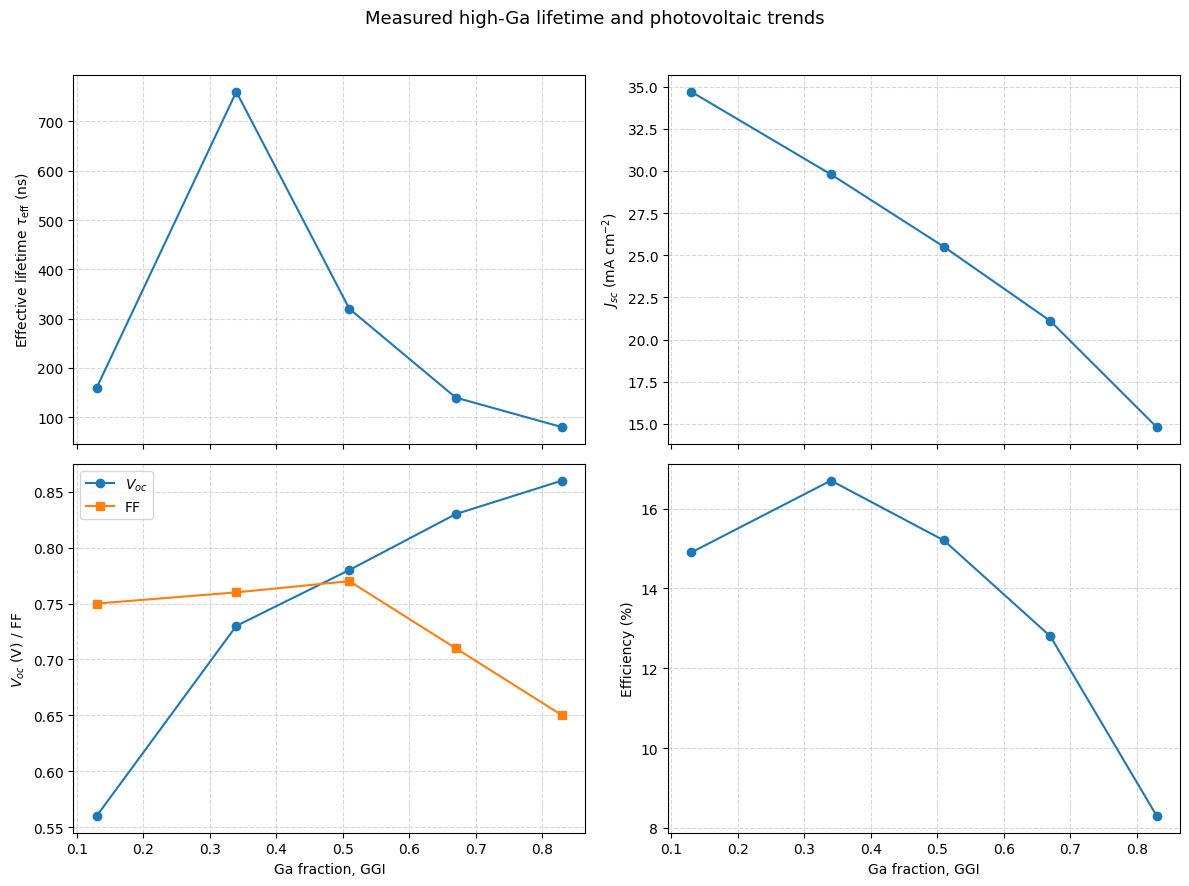

Saved: /content/drive/MyDrive/Colab Notebooks/PV_Layer_Opt/Figures_REVISED_VALIDATION/Fig4_Thomas_HighGa_Trends.pdf
Saved: /content/drive/MyDrive/Colab Notebooks/PV_Layer_Opt/Figures_REVISED_VALIDATION/Fig4_Thomas_HighGa_Trends.png


In [16]:

# Cell 13 — Revised Figure 4: Thomas high-Ga experimental trends
# ============================================================
# This figure presents measured trends only. It demonstrates why
# composition-independent transport quality is not experimentally
# representative across the full CIGS composition range.
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True)

axes[0, 0].plot(thomas_table["x"], thomas_table["tau_ns"], "o-")
axes[0, 0].set_ylabel(r"Effective lifetime $\tau_{\mathrm{eff}}$ (ns)")

axes[0, 1].plot(thomas_table["x"], thomas_table["Jsc_exp_mAcm2"], "o-")
axes[0, 1].set_ylabel(r"$J_{sc}$ (mA cm$^{-2}$)")

axes[1, 0].plot(thomas_table["x"], thomas_table["Voc_exp_V"], "o-", label=r"$V_{oc}$")
axes[1, 0].plot(thomas_table["x"], thomas_table["FF_exp"], "s-", label="FF")
axes[1, 0].set_ylabel(r"$V_{oc}$ (V) / FF")
axes[1, 0].legend()

axes[1, 1].plot(thomas_table["x"], thomas_table["eta_exp_percent"], "o-")
axes[1, 1].set_ylabel("Efficiency (%)")

for ax in axes.flat:
    ax.grid(True, linestyle="--", alpha=0.5)

for ax in axes[1, :]:
    ax.set_xlabel("Ga fraction, GGI")

fig.suptitle("Measured high-Ga lifetime and photovoltaic trends", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.96])

fig4_pdf = os.path.join(FIG_DIR, "Fig4_Thomas_HighGa_Trends.pdf")
fig4_png = os.path.join(FIG_DIR, "Fig4_Thomas_HighGa_Trends.png")
plt.savefig(fig4_pdf, bbox_inches="tight")
plt.savefig(fig4_png, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig4_pdf)
print("Saved:", fig4_png)


In [17]:

# Cell 14 — Optional Bissig passivated-EBIC profile figure
# ============================================================
# Bissig et al. report a depth-resolved collection profile, not a
# uniquely defined scalar diffusion length. This cell plots digitized
# passivated-EBIC data when a CSV is supplied.
# ============================================================
if os.path.exists(BISSIG_EBIC_CSV):
    bissig_ebic = pd.read_csv(BISSIG_EBIC_CSV)
    required = {"depth_um", "collection_probability"}
    missing = required.difference(bissig_ebic.columns)
    if missing:
        raise ValueError(
            f"Bissig EBIC CSV is missing columns: {sorted(missing)}"
        )

    bissig_ebic = bissig_ebic.sort_values("depth_um")

    plt.figure(figsize=(7.5, 5.0))
    plt.plot(
        bissig_ebic["depth_um"],
        bissig_ebic["collection_probability"],
        "o-",
        label="Passivated EBIC, digitized"
    )
    plt.xlabel("Depth from junction (µm)")
    plt.ylabel("Normalized collection probability")
    plt.title("Bissig et al. passivated cross-sectional EBIC profile")
    plt.ylim(0, 1.05)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()

    bissig_pdf = os.path.join(FIG_DIR, "Fig_Bissig_Passivated_EBIC.pdf")
    bissig_png = os.path.join(FIG_DIR, "Fig_Bissig_Passivated_EBIC.png")
    plt.savefig(bissig_pdf, bbox_inches="tight")
    plt.savefig(bissig_png, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", bissig_pdf)
    print("Saved:", bissig_png)
else:
    print("Bissig digitized EBIC CSV not found:")
    print(BISSIG_EBIC_CSV)
    print("This case remains a separate collection-profile check.")
    print("Do not substitute EBIC FWHM directly for scalar diffusion length L.")


Bissig digitized EBIC CSV not found:
/content/drive/MyDrive/Colab Notebooks/PV_Layer_Opt/Validation_Data/Bissig_2016_passivated_EBIC_digitized.csv
This case remains a separate collection-profile check.
Do not substitute EBIC FWHM directly for scalar diffusion length L.


In [18]:
# Cell 15 — S-Q current-limit audit
# ============================================================
# Final S-Q audit using nominal model
# ============================================================
sq_rows = []
n_violations = 0

print("=" * 95)
print("FINAL S-Q AUDIT")
print("=" * 95)
print(f"{'x':>5s} {'L_um':>6s} {'d_um':>6s} {'Jsc_raw':>10s} {'Jsc_SQ':>10s} {'ratio':>8s} {'flag':>6s}")
print("-" * 95)

for x in [0.00, 1.00]:
    for L_um in [0.3, 1.5, 3.0]:
        for d_um in [0.5, 1.5, 3.0]:
            r = device_metrics_model(
                x=x,
                d=d_um * 1e-6,
                L_um=L_um,
                form="quadratic",
                alpha_pen=1.0
            )

            Jsc_raw = r["Jsc"] * 0.1  # A/m^2 -> mA/cm^2
            Jsc_SQ = SQ_Jsc_limit(bandgap(x)) * 0.1
            ratio = Jsc_raw / Jsc_SQ
            flag = "ok" if ratio <= 1.0 else "CAP"

            if flag != "ok":
                n_violations += 1

            sq_rows.append((x, L_um, d_um, Jsc_raw, Jsc_SQ, ratio, flag))

            print(f"{x:5.2f} {L_um:6.2f} {d_um:6.2f} "
                  f"{Jsc_raw:10.2f} {Jsc_SQ:10.2f} {ratio:8.3f} {flag:>6s}")

print(f"\nS-Q violations: {n_violations} / {len(sq_rows)}")

# Save S-Q audit
sq_csv = os.path.join(RESULTS_DIR, "SQ_audit_final.csv")
with open(sq_csv, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["x", "L_um", "d_um", "Jsc_raw_mAcm2", "Jsc_SQ_mAcm2", "ratio", "flag"])
    writer.writerows(sq_rows)

print("Saved:", sq_csv)


FINAL S-Q AUDIT
    x   L_um   d_um    Jsc_raw     Jsc_SQ    ratio   flag
-----------------------------------------------------------------------------------------------
 0.00   0.30   0.50      36.18      47.26    0.766     ok
 0.00   0.30   1.50      35.44      47.26    0.750     ok
 0.00   0.30   3.00      35.38      47.26    0.749     ok
 0.00   1.50   0.50      36.78      47.26    0.778     ok
 0.00   1.50   1.50      38.09      47.26    0.806     ok
 0.00   1.50   3.00      38.57      47.26    0.816     ok
 0.00   3.00   0.50      36.80      47.26    0.779     ok
 0.00   3.00   1.50      38.32      47.26    0.811     ok
 0.00   3.00   3.00      39.11      47.26    0.827     ok
 1.00   0.30   0.50      18.07      24.17    0.748     ok
 1.00   0.30   1.50      17.74      24.17    0.734     ok
 1.00   0.30   3.00      17.68      24.17    0.732     ok
 1.00   1.50   0.50      18.37      24.17    0.760     ok
 1.00   1.50   1.50      19.17      24.17    0.793     ok
 1.00   1.50   3.0

In [19]:
# Cell 16 — Conditional composition–thickness design sweep
# ============================================================
# Conditional sweep over prescribed compositions and diffusion lengths
# ============================================================
results_final = {L: {} for L in L_um_list}
optima_final = {L: {} for L in L_um_list}

for L_um in L_um_list:
    for x in x_vals:
        arr_Jsc = np.zeros_like(thickness_m)
        arr_Voc = np.zeros_like(thickness_m)
        arr_FF  = np.zeros_like(thickness_m)
        arr_eta = np.zeros_like(thickness_m)

        for i, d in enumerate(thickness_m):
            r = device_metrics_model(
                x=x,
                d=d,
                L_um=L_um,
                form="quadratic",
                alpha_pen=1.0
            )

            arr_Jsc[i] = r["Jsc"]
            arr_Voc[i] = r["Voc"]
            arr_FF[i]  = r["FF"]
            arr_eta[i] = r["eta"]

        results_final[L_um][x] = {
            "Jsc": arr_Jsc,
            "Voc": arr_Voc,
            "FF": arr_FF,
            "eta": arr_eta
        }

        idx = int(np.argmax(arr_eta))

        optima_final[L_um][x] = {
            "d_opt": thickness_um[idx],
            "eta_max": arr_eta[idx],
            "Jsc_mAcm2": arr_Jsc[idx] * 0.1,
            "Voc": arr_Voc[idx],
            "FF": arr_FF[idx]
        }

# Print and save final design table
design_rows = []

print("=" * 90)
print("FINAL DESIGN-POINT TABLE")
print("=" * 90)
print(f"{'L_um':>6s} {'x':>6s} {'d_opt':>8s} {'eta':>8s} {'Jsc':>9s} {'Voc':>8s} {'FF':>7s}")
print("-" * 90)

for L_um in L_um_list:
    for x in x_vals:
        o = optima_final[L_um][x]

        row = [
            L_um, x, o["d_opt"], o["eta_max"],
            o["Jsc_mAcm2"], o["Voc"], o["FF"]
        ]
        design_rows.append(row)

        print(f"{L_um:6.2f} {x:6.2f} {o['d_opt']:8.3f} {o['eta_max']:8.2f} "
              f"{o['Jsc_mAcm2']:9.2f} {o['Voc']:8.3f} {o['FF']:7.3f}")

design_csv = os.path.join(RESULTS_DIR, "final_design_points.csv")
with open(design_csv, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["L_um", "x", "d_opt_um", "eta_percent", "Jsc_mAcm2", "Voc_V", "FF"])
    writer.writerows(design_rows)

print("Saved:", design_csv)


FINAL DESIGN-POINT TABLE
  L_um      x    d_opt      eta       Jsc      Voc      FF
------------------------------------------------------------------------------------------
  0.30   0.00    0.300    12.97     35.68    0.443   0.690
  0.30   0.31    0.312    16.97     31.99    0.595   0.748
  0.30   0.45    0.324    17.73     28.77    0.672   0.771
  0.30   0.66    0.336    19.45     25.52    0.801   0.799
  0.30   1.00    0.348    18.56     17.98    1.036   0.837
  0.70   0.00    0.384    13.88     36.37    0.460   0.697
  0.70   0.31    0.408    17.88     32.53    0.613   0.753
  0.70   0.45    0.432    18.61     29.26    0.690   0.775
  0.70   0.66    0.443    20.29     25.91    0.820   0.803
  0.70   1.00    0.515    19.28     18.33    1.053   0.839
  1.50   0.00    0.634    14.31     37.05    0.465   0.698
  1.50   0.31    0.837    18.40     33.38    0.615   0.753
  1.50   0.45    0.980    19.20     30.20    0.690   0.774
  1.50   0.66    1.052    20.90     26.74    0.819   0.802

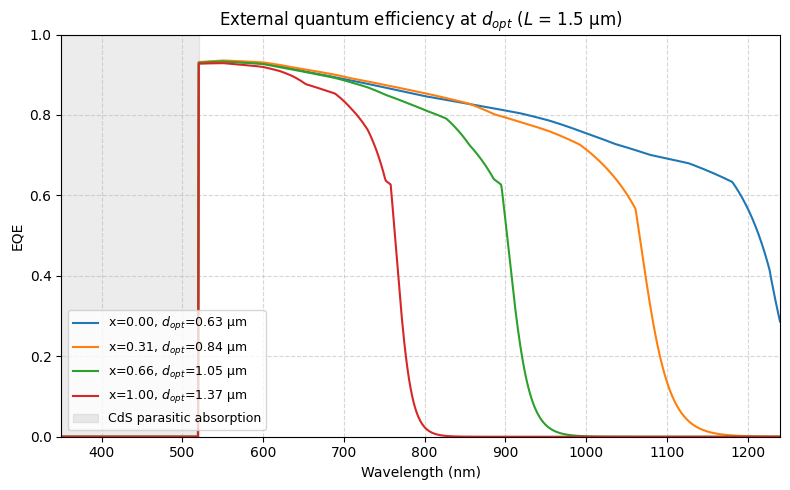

Saved: /content/drive/MyDrive/Colab Notebooks/PV_Layer_Opt/Figures_REVISED_VALIDATION/Fig_EQE_Conditional.pdf
Saved: /content/drive/MyDrive/Colab Notebooks/PV_Layer_Opt/Figures_REVISED_VALIDATION/Fig_EQE_Conditional.png


In [20]:
# Cell 17 — Conditional EQE curves at model-derived optimum
# ============================================================
# Final Figure 2: EQE at final d_opt
# ============================================================
L_show = 1.5
x_show_list = [0.00, 0.31, 0.66, 1.00]

plt.figure(figsize=(8, 5))

for x in x_show_list:
    if x not in x_vals:
        continue

    d_opt_um = optima_final[L_show][x]["d_opt"]
    d_opt_m = d_opt_um * 1e-6

    r = device_metrics_model(
        x=x,
        d=d_opt_m,
        L_um=L_show,
        form="quadratic",
        alpha_pen=1.0
    )

    EQE = r["EQE"].copy()

    # Display convention: photons below 520 nm are parasitically absorbed in CdS.
    EQE_display = np.where(wl_nm < CdS_CUTOFF_NM, 0.0, EQE)

    plt.plot(
        wl_nm,
        EQE_display,
        label=f"x={x:.2f}, $d_{{opt}}$={d_opt_um:.2f} µm"
    )

plt.axvspan(
    350, CdS_CUTOFF_NM,
    color="gray",
    alpha=0.15,
    label="CdS parasitic absorption"
)

plt.xlabel("Wavelength (nm)")
plt.ylabel("EQE")
plt.title(f"External quantum efficiency at $d_{{opt}}$ ($L$ = {L_show} µm)")
plt.xlim(350, 1240)
plt.ylim(0, 1.0)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=9)
plt.tight_layout()

fig2_pdf = os.path.join(FIG_DIR, "Fig_EQE_Conditional.pdf")
fig2_png = os.path.join(FIG_DIR, "Fig_EQE_Conditional.png")

plt.savefig(fig2_pdf)
plt.savefig(fig2_png, dpi=300)
plt.show()

print("Saved:", fig2_pdf)
print("Saved:", fig2_png)


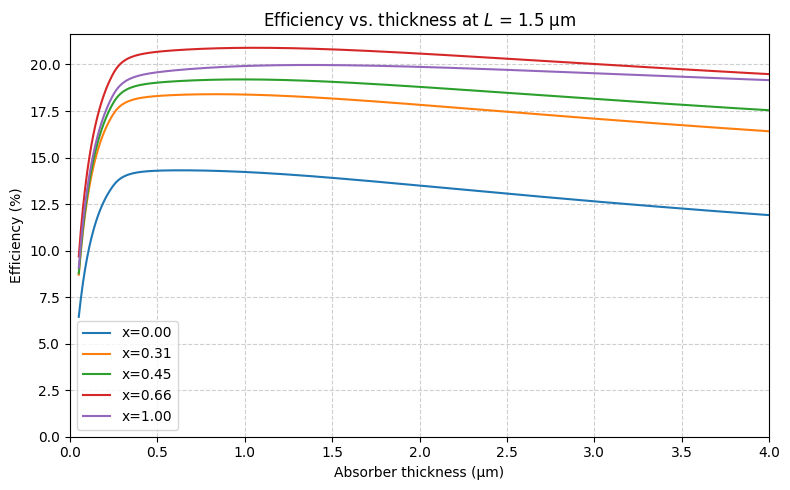

Saved: /content/drive/MyDrive/Colab Notebooks/PV_Layer_Opt/Figures_REVISED_VALIDATION/Fig_Eff_vs_d_Conditional.pdf
Saved: /content/drive/MyDrive/Colab Notebooks/PV_Layer_Opt/Figures_REVISED_VALIDATION/Fig_Eff_vs_d_Conditional.png


In [21]:
# Cell 18 — Conditional efficiency-versus-thickness curves
# ============================================================
# Final Figure 4: Efficiency vs thickness at L=1.5 µm
# Cropped to 0–4 µm to focus on relevant design regime.
# ============================================================
plt.figure(figsize=(8, 5))

for x in x_vals:
    plt.plot(
        thickness_um,
        results_final[1.5][x]["eta"],
        label=f"x={x:.2f}"
    )

plt.xlabel("Absorber thickness (µm)")
plt.ylabel("Efficiency (%)")
plt.title("Efficiency vs. thickness at $L$ = 1.5 µm")
plt.xlim(0, 4.0)
plt.ylim(bottom=0)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()

fig4_pdf = os.path.join(FIG_DIR, "Fig_Eff_vs_d_Conditional.pdf")
fig4_png = os.path.join(FIG_DIR, "Fig_Eff_vs_d_Conditional.png")

plt.savefig(fig4_pdf)
plt.savefig(fig4_png, dpi=300)
plt.show()

print("Saved:", fig4_pdf)
print("Saved:", fig4_png)


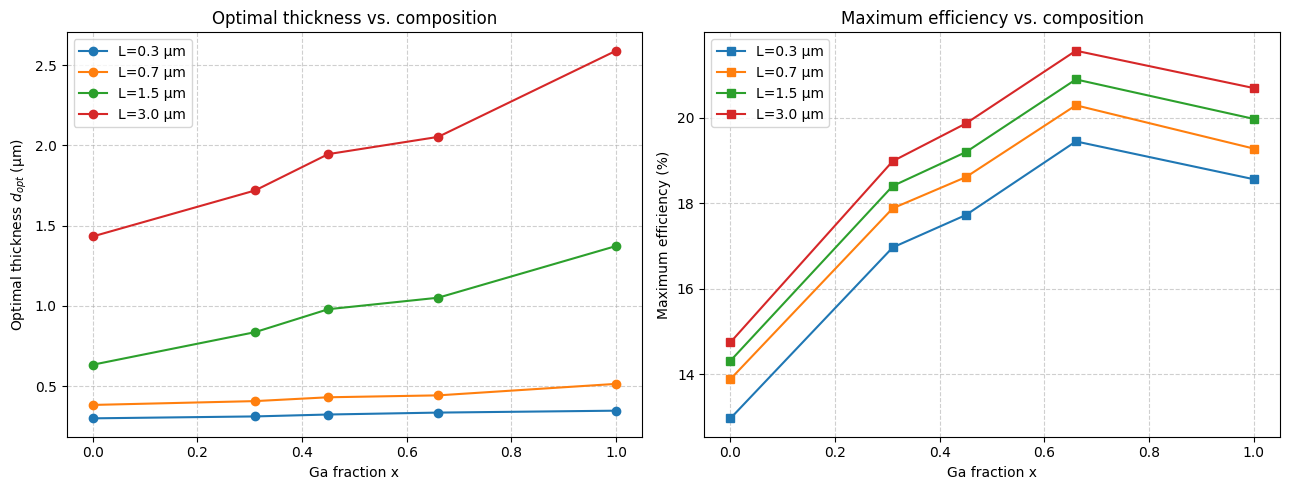

Saved: /content/drive/MyDrive/Colab Notebooks/PV_Layer_Opt/Figures_REVISED_VALIDATION/Fig_DesignMaps_Conditional.pdf
Saved: /content/drive/MyDrive/Colab Notebooks/PV_Layer_Opt/Figures_REVISED_VALIDATION/Fig_DesignMaps_Conditional.png


In [22]:
# Cell 19 — Conditional design maps
# ============================================================
# Conditional composition-resolved design maps
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for L_um in L_um_list:
    d_opt = [optima_final[L_um][x]["d_opt"] for x in x_vals]
    eta_max = [optima_final[L_um][x]["eta_max"] for x in x_vals]

    axes[0].plot(x_vals, d_opt, "o-", label=f"L={L_um} µm")
    axes[1].plot(x_vals, eta_max, "s-", label=f"L={L_um} µm")

axes[0].set_xlabel("Ga fraction x")
axes[0].set_ylabel("Optimal thickness $d_{opt}$ (µm)")
axes[0].set_title("Optimal thickness vs. composition")

axes[1].set_xlabel("Ga fraction x")
axes[1].set_ylabel("Maximum efficiency (%)")
axes[1].set_title("Maximum efficiency vs. composition")

for ax in axes:
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend()

plt.tight_layout()

fig5_pdf = os.path.join(FIG_DIR, "Fig_DesignMaps_Conditional.pdf")
fig5_png = os.path.join(FIG_DIR, "Fig_DesignMaps_Conditional.png")

plt.savefig(fig5_pdf)
plt.savefig(fig5_png, dpi=300)
plt.show()

print("Saved:", fig5_pdf)
print("Saved:", fig5_png)


SENSITIVITY ANALYSIS
Base efficiency = 18.040 %
------------------------------------------------------------------------------------------
Parameter               low         high    eta_low   eta_high      span%
$n_{ideal}$        1.20e+00     1.80e+00     23.191     13.181     -55.48
$S_{back}$         1.00e+03     1.00e+06     18.655     17.897      -4.20
$R_{front}$        4.00e-02     1.50e-01     19.105     16.811     -12.72
$W_{dep}$          1.00e-07     4.00e-07     17.322     18.416       6.06
$R_{back}$         5.00e-01     9.50e-01     17.991     18.080       0.50


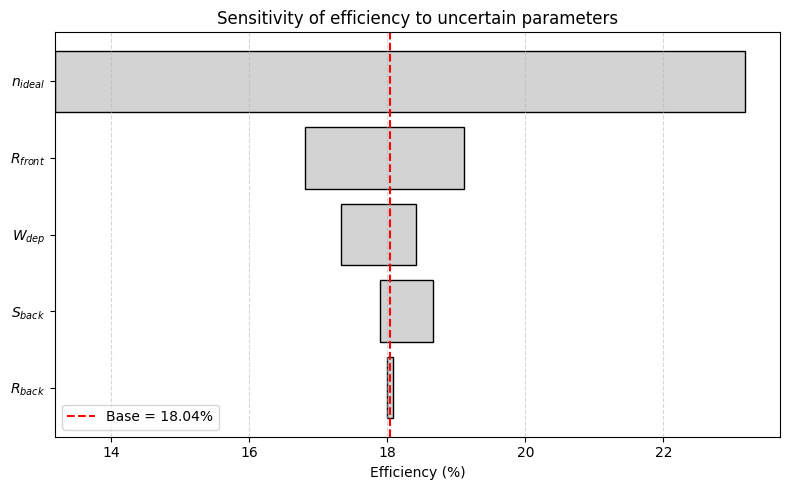

Saved: /content/drive/MyDrive/Colab Notebooks/PV_Layer_Opt/Results_REVISED_VALIDATION/sensitivity_final.csv
Saved: /content/drive/MyDrive/Colab Notebooks/PV_Layer_Opt/Figures_REVISED_VALIDATION/Fig_Sensitivity_Revised.pdf
Saved: /content/drive/MyDrive/Colab Notebooks/PV_Layer_Opt/Figures_REVISED_VALIDATION/Fig_Sensitivity_Revised.png


In [23]:
# Cell 20 — Sensitivity analysis
# ============================================================
# Final sensitivity analysis using final model
# ============================================================
x0 = 0.30
L0_um = 1.5
d0_m = 1.5e-6

def eta_final_with(R_front_scalar=None,
                   R_back=R_BACK,
                   W=W_DEP,
                   S_b=S_BACK_CM_S,
                   n=N_IDEALITY):
    if R_front_scalar is None:
        R_front_l = R_FRONT_lambda_TMM
    else:
        R_front_l = np.full_like(wl_nm, R_front_scalar)

    r = device_metrics_model(
        x=x0,
        d=d0_m,
        L_um=L0_um,
        form="quadratic",
        alpha_pen=1.0,
        W=W,
        S_b=S_b,
        n=n,
        R_s=R_S_SI,
        R_back=R_back,
        R_front_l=R_front_l
    )

    return r["eta"]

base_eta = eta_final_with()

sens_params = [
    ("$n_{ideal}$", "n", 1.2, 1.8),
    ("$S_{back}$", "S_b", 1e3, 1e6),
    ("$R_{front}$", "R_front_scalar", 0.04, 0.15),
    ("$W_{dep}$", "W", 0.10e-6, 0.40e-6),
    ("$R_{back}$", "R_back", 0.50, 0.95),
]

sensitivity_rows = []

print("=" * 90)
print("SENSITIVITY ANALYSIS")
print("=" * 90)
print(f"Base efficiency = {base_eta:.3f} %")
print("-" * 90)
print(f"{'Parameter':<14s} {'low':>12s} {'high':>12s} {'eta_low':>10s} {'eta_high':>10s} {'span%':>10s}")

for label, kw, lo, hi in sens_params:
    eta_lo = eta_final_with(**{kw: lo})
    eta_hi = eta_final_with(**{kw: hi})
    span = 100.0 * (eta_hi - eta_lo) / base_eta

    sensitivity_rows.append((label, kw, lo, hi, eta_lo, eta_hi, span))

    print(f"{label:<14s} {lo:12.2e} {hi:12.2e} {eta_lo:10.3f} {eta_hi:10.3f} {span:10.2f}")

# Sort by absolute span for plotting
sensitivity_rows_sorted = sorted(sensitivity_rows, key=lambda r: abs(r[6]), reverse=True)

labels = [r[0] for r in sensitivity_rows_sorted]
eta_lows = np.array([r[4] for r in sensitivity_rows_sorted])
eta_highs = np.array([r[5] for r in sensitivity_rows_sorted])
lefts = np.minimum(eta_lows, eta_highs)
widths = np.abs(eta_highs - eta_lows)

ypos = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    ypos,
    widths,
    left=lefts,
    color="lightgray",
    edgecolor="black"
)

ax.axvline(
    base_eta,
    color="red",
    linestyle="--",
    label=f"Base = {base_eta:.2f}%"
)

ax.set_yticks(ypos)
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel("Efficiency (%)")
ax.set_title("Sensitivity of efficiency to uncertain parameters")
ax.grid(axis="x", linestyle="--", alpha=0.5)
ax.legend()

plt.tight_layout()

fig6_pdf = os.path.join(FIG_DIR, "Fig_Sensitivity_Revised.pdf")
fig6_png = os.path.join(FIG_DIR, "Fig_Sensitivity_Revised.png")

plt.savefig(fig6_pdf)
plt.savefig(fig6_png, dpi=300)
plt.show()

# Save sensitivity table
sens_csv = os.path.join(RESULTS_DIR, "sensitivity_final.csv")
with open(sens_csv, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["label", "parameter", "low", "high", "eta_low", "eta_high", "span_percent_of_base"])
    writer.writerows(sensitivity_rows)

print("Saved:", sens_csv)
print("Saved:", fig6_pdf)
print("Saved:", fig6_png)


In [24]:

# Cell 21 — Revised validation and manuscript-number summary
# ============================================================
print("=" * 105)
print("REVISED EXTERNAL-VALIDATION SUMMARY")
print("=" * 105)

print("\n1) Performance at measured thickness")
display(table5.round(4))

print("\n2) Lundberg thickness-series benchmark")
print("Series:", lundberg_series_label)
print(
    f"Model L envelope: {L_LUNDBERG_GRID_UM.min():.2f}–"
    f"{L_LUNDBERG_GRID_UM.max():.2f} µm"
)
print("Direct uniform-composition comparison:", lundberg_is_direct_uniform_comparison)

print("\n3) Thomas high-Ga lifetime/performance series")
print(
    f"Lifetime-derived L intervals use D = {D_LO:.2f}–"
    f"{D_HI:.2f} cm^2/s"
)
display(thomas_table.round(4))

print("\n4) Bissig collection-profile check")
print("Digitized file available:", os.path.exists(BISSIG_EBIC_CSV))

print("\n5) S-Q audit")
print(f"S-Q violations = {n_violations} / {len(sq_rows)}")

print("\nINTERPRETATION NOTES")
print("- Do not report MAE in optimal thickness from fabricated device thicknesses.")
print("- Do not describe the Lundberg L range as independently measured.")
print("- Do not convert Bissig EBIC FWHM directly into scalar L.")
print("- Treat high-Ga composition maps as conditional projections.")
print("- The nominal quadratic penalty and alpha_pen=1 are assumptions, not")
print("  independently proven by the revised validation dataset.")


REVISED EXTERNAL-VALIDATION SUMMARY

1) Performance at measured thickness


,source,classification,transport_method,x,d_exp_um,L_um,Jsc_exp_mAcm2,Jsc_pred_mAcm2,Delta_Jsc_mAcm2,Voc_exp_V,Voc_pred_V,Delta_Voc_V,FF_exp,FF_pred,Delta_FF,eta_exp_percent,eta_pred_percent,Delta_eta_pp
0,Nichterwitz et al. (2013),Primary scalar-L case,cross-sectional EBIC,0.0,2.0,0.42,40.5,36.2072,-4.2928,0.46,0.3477,-0.1123,0.717,0.6368,-0.0802,13.4,9.5406,-3.8594



2) Lundberg thickness-series benchmark
Series: Ga-back-graded tabulated benchmark
Model L envelope: 0.30–3.00 µm
Direct uniform-composition comparison: False

3) Thomas high-Ga lifetime/performance series
Lifetime-derived L intervals use D = 1.00–3.00 cm^2/s


,x,tau_ns,L_lo_um,L_hi_um,Jsc_exp_mAcm2,Voc_exp_V,FF_exp,eta_exp_percent
0,0.13,160,4.0000,6.9282,34.7,0.56,0.75,14.9
1,0.34,760,8.7178,15.0997,29.8,0.73,0.76,16.7
2,0.51,320,5.6569,9.7980,25.5,0.78,0.77,15.2
3,0.67,140,3.7417,6.4807,21.1,0.83,0.71,12.8
4,0.83,80,2.8284,4.8990,14.8,0.86,0.65,8.3



4) Bissig collection-profile check
Digitized file available: False

5) S-Q audit
S-Q violations = 0 / 18

INTERPRETATION NOTES
- Do not report MAE in optimal thickness from fabricated device thicknesses.
- Do not describe the Lundberg L range as independently measured.
- Do not convert Bissig EBIC FWHM directly into scalar L.
- Treat high-Ga composition maps as conditional projections.
- The nominal quadratic penalty and alpha_pen=1 are assumptions, not
  independently proven by the revised validation dataset.


In [25]:
# Cell 22 — Repository and data-file checklist
# ============================================================
# Repository / Zenodo checklist
# ============================================================
print("Recommended repository contents:")
print("""
README.md
requirements.txt
LICENSE
notebooks/
    Coupled_Optical_Transport_Revised_Validation.ipynb
data/
    README.md
    Validation_Data/
        Lundberg_2003_homogeneous_digitized.csv
        Bissig_2016_passivated_EBIC_digitized.csv
""")

print("Zenodo DOI:")
print("https://doi.org/10.5281/zenodo.20325908")

print("\nRecommended Data and Code Availability statement:")
print("""
The Google Colab notebook implementing the coupled optical–electrical CIGS absorber-thickness
optimization model is archived on Zenodo at https://doi.org/10.5281/zenodo.20325908.
The optical constants used as model input were obtained from the experimental CuIn1-xGaxSe2
measurements reported by Paulson et al. and should be cited through the original source
publication. The raw Paulson optical-constant files are not redistributed in the archive;
instructions for obtaining and placing the source files are provided in the repository
data/README.md file.
""")


Recommended repository contents:

README.md
requirements.txt
LICENSE
notebooks/
    Coupled_Optical_Transport_Revised_Validation.ipynb
data/
    README.md
    Validation_Data/
        Lundberg_2003_homogeneous_digitized.csv
        Bissig_2016_passivated_EBIC_digitized.csv

Zenodo DOI:
https://doi.org/10.5281/zenodo.20325908

Recommended Data and Code Availability statement:

The Google Colab notebook implementing the coupled optical–electrical CIGS absorber-thickness
optimization model is archived on Zenodo at https://doi.org/10.5281/zenodo.20325908.
The optical constants used as model input were obtained from the experimental CuIn1-xGaxSe2
measurements reported by Paulson et al. and should be cited through the original source
publication. The raw Paulson optical-constant files are not redistributed in the archive;
instructions for obtaining and placing the source files are provided in the repository
data/README.md file.

